# Retrieval-Centric Deep Learning in Growing Nonparametric Neural Networks

Retrieval-Centric Deep Learning (RCDL) proposes a general-purpose layer for deep learning that, instead of compressing arbitrary-size training data into fixed-size weight matrices via gradients i.e. $W \leftarrow W - \eta \nabla_W \ell$, stores a new pair of key-value representations for every data point during training. At inference time, it then retrieves
and recombines these representations through an attention mechanism resulting in a growing neural net (NN) in width over the course of training. See the Table 1 from our paper below for an illustrative comparison of common weight learning vs. of our new family of RCDL layers.


We derive such a “retrieval-centric deep learning” paradigm from the classic duality of a linear layer trained by gradient descent as a type of linear attention (LA) over the training data points—
which motivates us to replace the corresponding LA by a more powerful form of
attention from recent work on sequence models, namely, kernelized attention using radial basis function (RBF) and softmax-like kernels. Please see our paper  [[LINK TODO]](https://) for more details.


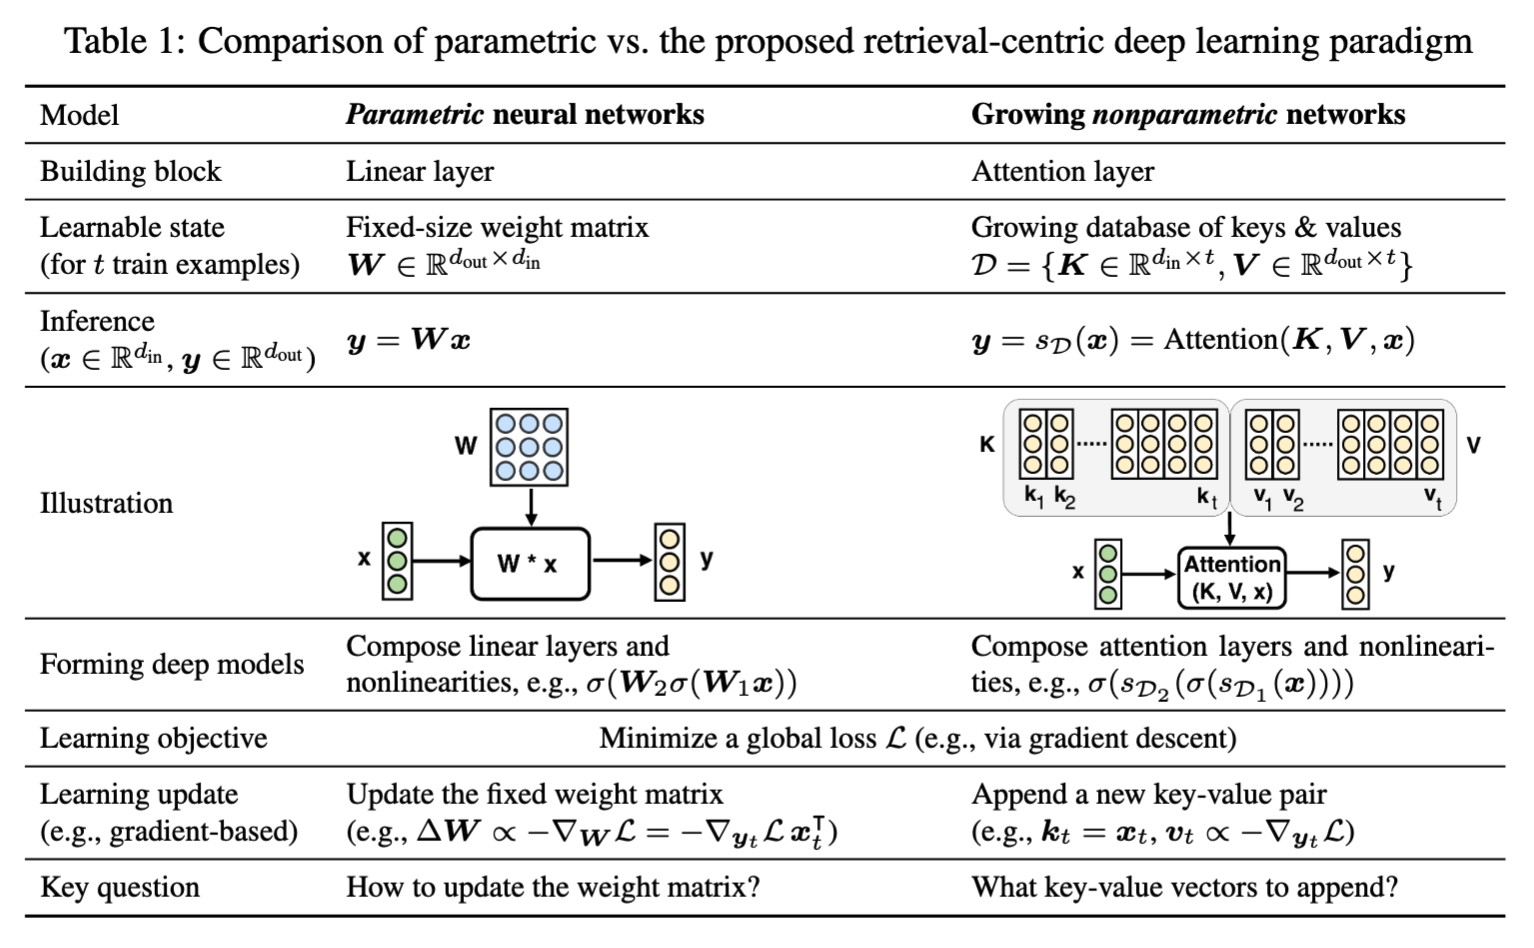






This interactive notebook accompanies our paper and demonstrates **single-epoch online learning on CIFAR-10** using growing nonparametric RCDL layers alongside parametric baselines.


In [1]:
#@title 1. Setup & Dependencies
import dataclasses as dc
import math
import os
import tarfile
import time
import urllib.request
from typing import Any, Dict, Optional, Tuple

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Paper Color Palette & Plot Aesthetics
METHOD_PALETTE = {
    "Mesa": "#f48fb1",
    "Delta": "#b692f4",
    "Muon": "#ffca28",
    "Weighted Softmax": "#1976D2",
    "RBF": "#a3c1e1",
    "AdamW": "#689f38",
    "Adam": "#9ccc65",
    "RMSprop": "#c5e1a5",
    "SGD": "#9E9E9E",
    "kNN": "#6610f2",
    "SVM": "#000000",
}
OPTIMIZER_PALETTE = {'adam': '#9ccc65', 'adamw': '#689f38', 'rmsprop': '#c5e1a5', 'sgd': '#9E9E9E', 'muon': '#ffca28'}


def style_paper_ax(
    ax: plt.Axes,
    fontsize_ticks: int = 13,
    linewidth_x: float = 1.5,
    linewidth_y: float = 1.5,
    show_grid: bool = False,
):
  """Applies the paper spine, tick, and grid aesthetic to a Matplotlib Axes."""
  ax.spines["top"].set_visible(False)
  ax.spines["right"].set_visible(False)
  ax.spines["bottom"].set_linewidth(linewidth_x)
  ax.spines["left"].set_linewidth(linewidth_y)
  ax.tick_params(axis="both", which="major", labelsize=fontsize_ticks)
  if show_grid:
    ax.grid(True, linestyle="--", alpha=0.5)
  else:
    ax.grid(False)


print(f"PyTorch version: {torch.__version__}")
print(f"Device:          {DEVICE}" + (f" ({torch.cuda.get_device_name(0)})" if DEVICE.type == 'cuda' else ''))

PyTorch version: 2.14.0+cu130
Device:          cuda (NVIDIA H200)


## 2. CIFAR-10 Data Pipeline

Loads CIFAR-10 (`50,000` training and `10,000` test images), flattens each image to $d_{\text{in}} = 3{,}072$ features, and standardizes per channel. During training, the model sees the `50,000` training images **once** in a single online pass (`1` epoch).


In [2]:
#@title 2.1 Load & Standardize CIFAR-10

CIFAR_ROOT = "data"  # @param {type:"string"}
CIFAR_URL = 'https://www.cs.toronto.edu/~kriz/cifar-10-binary.tar.gz'
CIFAR_MEAN = np.array([0.4914, 0.4822, 0.4465], dtype=np.float32)
CIFAR_STD = np.array([0.2470, 0.2435, 0.2616], dtype=np.float32)
CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


def load_cifar10(root: str) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
  """Loads the CIFAR-10 binary release (downloaded once into `root`) into standardized flat float32 arrays."""
  data_dir = os.path.join(root, 'cifar-10-batches-bin')
  if not os.path.exists(os.path.join(data_dir, 'test_batch.bin')):
    os.makedirs(root, exist_ok=True)
    archive = os.path.join(root, 'cifar-10-binary.tar.gz')
    print(f'Downloading {CIFAR_URL} ...')
    urllib.request.urlretrieve(CIFAR_URL, archive)
    with tarfile.open(archive) as tar:
      tar.extractall(root, filter='data')

  def read(files):
    raw = np.concatenate([np.fromfile(f, dtype=np.uint8) for f in files]).reshape(-1, 3073)
    images = raw[:, 1:].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1).astype(np.float32) / 255.0
    return ((images - CIFAR_MEAN) / CIFAR_STD).reshape(len(raw), -1), raw[:, 0].astype(np.int64)

  train_x, train_y = read([os.path.join(data_dir, f'data_batch_{i}.bin') for i in range(1, 6)])
  test_x, test_y = read([os.path.join(data_dir, 'test_batch.bin')])
  return train_x, train_y, test_x, test_y


def unnormalize_cifar(flat_imgs: np.ndarray) -> np.ndarray:
  """Inverts CIFAR_MEAN / CIFAR_STD standardization back to [0, 1] RGB (..., 32, 32, 3)."""
  return np.clip(flat_imgs.reshape((-1, 32, 32, 3)) * CIFAR_STD + CIFAR_MEAN, 0.0, 1.0)


train_images, train_labels, test_images, test_labels = load_cifar10(CIFAR_ROOT)
train_x, train_y = torch.as_tensor(train_images, device=DEVICE), torch.as_tensor(train_labels, device=DEVICE)
test_x, test_y = torch.as_tensor(test_images, device=DEVICE), torch.as_tensor(test_labels, device=DEVICE)
print(f"Train images: {train_images.shape}, Labels: {train_labels.shape}")
print(f"Test images:  {test_images.shape}, Labels: {test_labels.shape}")

Train images: (50000, 3072), Labels: (50000,)
Test images:  (10000, 3072), Labels: (10000,)


## 3. Model Architecture

All models share the same residual-stream backbone: $L$ pre-norm residual blocks followed by a readout layer. In the ResNet-MLP baseline, each block is a standard feed-forward (FFN) layer acting on the RMS-normalized residual stream. The RCDL models replace these FFN layers (and the readout) with a *growing* layer that retrieves from a database $D = \{(w_j, \mathbf{k}_j, \tilde{\mathbf{v}}_j)\}_{j=1}^{N}$ of keys $\mathbf{k}_j \in \mathbb{R}^{d_{\text{in}}}$, weighted values $\tilde{\mathbf{v}}_j = w_j \mathbf{v}_j \in \mathbb{R}^{d_{\text{out}}}$, and scalar weights $w_j \ge 0$. For a query $\mathbf{q}$ (the normalized layer input), the **weighted softmax** models compute

$$z_j(\mathbf{q}) = \frac{\langle \mathbf{q}, \mathbf{k}_j \rangle}{T \sqrt{d_{\text{in}}}}, \qquad s_D(\mathbf{q}) = \frac{\sum_{j} \exp(z_j(\mathbf{q}))\, \tilde{\mathbf{v}}_j}{\sum_{m} w_m \exp(z_m(\mathbf{q}))},$$

with temperature $T$. The **Growing RBF** model instead uses an unnormalized Gaussian RBF kernel over a database $D = \{(\mathbf{k}_j, \mathbf{v}_j)\}_{j=1}^{N}$:

$$\phi_{\text{RBF}}(\mathbf{q}, \mathbf{k}_j) = \exp\!\left(-\frac{\lVert \mathbf{q} - \mathbf{k}_j \rVert_2^2}{2 T \sqrt{d_{\text{in}}}}\right), \qquad s_D(\mathbf{q}) = \sum_{j} \phi_{\text{RBF}}(\mathbf{q}, \mathbf{k}_j)\, \mathbf{v}_j .$$

The learning rules, i.e. how a new tuple $(w_t, \mathbf{k}_t, \tilde{\mathbf{v}}_t)$ is added for the current training data, are described in the corresponding sections below. You can train the following models in this notebook:


| Model | Core Mechanism | Database Growth | Parameter Updates |
| :--- | :--- | :--- | :--- |
| **Growing Weighted Softmax** | Weighted softmax attention; each new tuple is a (clipped) functional gradient step | One entry per training sample | Nonparametric (no backprop into the database) |
| **Gauge-Invariant Weighted Softmax** | Weighted softmax attention; gauge-invariant functional gradient step (strictly positive weights, no clipping) | One entry per training sample | Nonparametric (no backprop into the database) |
| **Growing RBF** | Unnormalized Gaussian RBF kernel attention | One entry per training sample | Nonparametric (no backprop into the database) |
| **Hybrid Growing Weighted Softmax** | Weighted softmax attention; only novel queries are added, all entries are refined by Adam | Sublinear (novel samples only) | Nonparametric growth + parametric (Adam) refinement |
| **Parametric Softmax** | Fixed-size weighted softmax table trained from random init | Fixed size (no growth) | Pure backpropagation (Adam) |
| **ResNet-MLP** | Standard dense residual network (`GELU`) | Fixed network width | Pure backpropagation (Adam) |

In [3]:
#@title 3.1 Architecture, Kernels & PyTorch Modules

@dc.dataclass(frozen=True)
class RCDLConfig:
  """Unified configuration for 'gws', 'gauge', 'rbf', 'hybrid', 'parametric_softmax', and 'standard'."""
  # --- Architecture ---
  kernel_type: str = 'gws'           # 'gws' | 'gauge' | 'rbf' | 'hybrid' | 'parametric_softmax' | 'standard'
  hidden_dim: int = 3072
  num_layers: int = 2
  nonlinearity: str = 'none'         # 'none' | 'gelu' | 'relu'
  use_residual: bool = True
  # --- Attention & Database (paper notation in comments) ---
  temperature: float = 10.0          # T (softmax temperature; RBF temperature for 'rbf')
  db_size: int = 50016               # N: max. database size per layer = 50,000 (1 epoch) + 16 (D_0)
  full_epoch_capacity: int = 50016   # Reference 1-epoch capacity for % calculation
  # --- Growing layers ('gws', 'gauge', 'rbf', 'hybrid') ---
  eta: float = 0.03                  # η: weight learning rate ('gws'/'gauge'/'hybrid'); value learning rate for 'rbf'
  beta: float = 30.0                 # β: value learning rate ('gws'/'gauge'/'hybrid'); unused for 'rbf'
  model_momentum: float = 0.0        # age-based momentum of the stored values (0 = off)
  model_weight_decay: float = 0.0    # age-based decay of the stored values (0 = off)
  init_pred_scale: float = 20.0      # 'rbf': scale of the frozen random projection (only if freeze_init_out=False)
  add_activations: bool = False      # 'rbf': also store the current prediction in the new value
  freeze_init_out: bool = True       # 'rbf': True = no frozen random projection x W_slow
  # --- Gauge-Invariant Weighted Softmax ('gauge') ---
  gauge_alpha: float = 1.0           # α: gauge parameter (α_t = α / ||g_t||)
  # --- Parametric Softmax ('parametric_softmax') Specific ---
  learn_parametric_weights: bool = True
  # --- Hybrid ('hybrid') Growth Control ---
  growth_threshold: float = 50.0     # τ: growth threshold on min_j ||q - k_j||_2
  # --- Data & Optimization ---
  num_classes: int = 10
  batch_size: int = 16
  optimizer: str = 'adam'            # 'adam' | 'adamw' | 'sgd' | 'rmsprop' | 'muon'
  weight_decay: float = 0.0
  learning_rate: float = 3e-4        # optimizer (e.g. Adam) learning rate for parametric parameters
  num_epochs: int = 1
  global_init_seed: int = 1

  @property
  def ref_capacity(self) -> int:
    """Reference 1-epoch capacity per layer for % reporting."""
    return self.full_epoch_capacity if self.kernel_type == 'parametric_softmax' else self.db_size


def rms_norm(x: torch.Tensor, eps: float = 1e-6) -> torch.Tensor:
  """RMSNorm without learned scale: the backbone's pre-norm, q = RMSNorm(x)."""
  return x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + eps)


def weighted_attention(q, keys, values, weights, temperature: float, db_size: Optional[int] = None):
  """Weighted softmax attention over the database entries: s_D(q) = Σ_j exp(z_j) ṽ_j / Σ_m w_m exp(z_m).

  z_j = <q, k_j> / (T sqrt(d_in)); the weights enter the denominator only. Empty entries (k_j = 0, w_j = 0) and,
  for 'hybrid', entries beyond the active database size are masked out.
  """
  logits = q @ keys.T / (temperature * math.sqrt(q.shape[-1]))
  valid = (keys != 0).any(-1) | (weights[:, 0] != 0)
  if db_size is not None:
    valid = valid & (torch.arange(keys.shape[0], device=q.device) < db_size)
  logits = torch.where(valid[None, :], logits, torch.full_like(logits, -1e9))
  exp_qk = torch.exp(logits - logits.max(-1, keepdim=True).values)
  denom = exp_qk @ weights
  sign = torch.where(denom < 0, -torch.ones_like(denom), torch.ones_like(denom))
  return (exp_qk @ values) / (denom.abs().clamp_min(1e-8) * sign)


def rbf_attention(q, keys, values, temperature: float):
  """Unnormalized Gaussian RBF kernel attention: s_D(q) = Σ_j exp(-||q - k_j||^2 / (2 T sqrt(d_in))) v_j."""
  dist_sq = (q.pow(2).sum(-1, keepdim=True) + keys.pow(2).sum(-1) - 2.0 * q @ keys.T).clamp_min(0.0)
  return torch.exp(-dist_sq / (2.0 * temperature * math.sqrt(q.shape[-1]))) @ values


def decay_mask(db_size: int, batch_size: int, db_idx: int, momentum: float, weight_decay: float, device):
  """Age-based momentum / weight-decay mask on the stored values ('gws', 'gauge', 'rbf')."""
  t = torch.arange(db_size, device=device)
  ages = torch.roll((db_size - t) % db_size // batch_size, batch_size - 1)
  mask = (1.0 - weight_decay) ** ages if weight_decay > 0.0 else torch.ones(db_size, device=device)
  if momentum > 0.0:
    mask = mask * (1.0 - momentum ** torch.roll(ages, batch_size)) / (1.0 - momentum + 1e-6)
  return torch.roll(torch.roll(mask, -batch_size), db_idx).float()[:, None]


class RCDLLayer(nn.Module):
  """Unified PyTorch module for 'gws', 'gauge', 'rbf', 'hybrid', and 'parametric_softmax' RCDL layers.

  The database (keys k_j, weighted values ṽ_j, weights w_j) consists of buffers for the growing layers ('gws',
  'gauge', 'rbf') and of nn.Parameters refined by the optimizer for 'hybrid' and 'parametric_softmax'. During
  training, a hook on the gradient of the layer output computes the new tuples (Section 4); commit() appends them
  to the database at the end of the step.
  """

  def __init__(self, cfg: RCDLConfig, d_in: int, d_out: int, layer_id: int, gen: torch.Generator):
    super().__init__()
    self.cfg, self.kind, self.T = cfg, cfg.kernel_type, cfg.temperature
    n, B = cfg.db_size, cfg.batch_size
    keys, values, weights = torch.zeros(n, d_in), torch.zeros(n, d_out), torch.zeros(n, 1)
    if self.kind == 'parametric_softmax':   # fixed-size random table, every entry active from the start
      keys = torch.randn(n, d_in, generator=gen) / math.sqrt(d_in)
      values = torch.randn(n, d_out, generator=gen) * 0.02
      weights = torch.ones(n, 1)
      self.size = n
    elif self.kind == 'rbf':                # empty database (+ optional frozen random projection x W_slow)
      self.size = 0
      if not cfg.freeze_init_out:
        g = torch.Generator().manual_seed(layer_id * 42)
        self.register_buffer('w_slow', torch.randn(d_in, d_out, generator=g) / (math.sqrt(d_in) * cfg.init_pred_scale))
    else:                                   # D_0: B random RMS-normalized entries with weight 1/B
      keys[:B] = rms_norm(torch.randn(B, d_in, generator=gen))
      values[:B] = rms_norm(torch.randn(B, d_out, generator=gen))
      weights[:B] = 1.0 / B
      self.size = B
    learned = {'hybrid': ('keys', 'values', 'weights'),
               'parametric_softmax': ('keys', 'values') + (('weights',) if cfg.learn_parametric_weights else ())}
    for name, t in (('keys', keys), ('values', values), ('weights', weights)):
      if name in learned.get(self.kind, ()):
        setattr(self, name, nn.Parameter(t))
      else:
        self.register_buffer(name, t)
    self.next_row, self.pending = self.size, None

  def forward(self, q: torch.Tensor) -> torch.Tensor:
    cfg = self.cfg
    if self.kind == 'parametric_softmax':
      return weighted_attention(q, self.keys, self.values, self.weights, self.T)
    if self.kind == 'hybrid':
      s = weighted_attention(q, self.keys, self.values, self.weights, self.T, self.size)
    else:
      values = self.values
      if cfg.model_momentum > 0.0 or cfg.model_weight_decay > 0.0:
        values = values * decay_mask(len(values), q.shape[0], self.next_row, cfg.model_momentum,
                                     cfg.model_weight_decay, q.device)
      if self.kind == 'rbf':
        s = rbf_attention(q, self.keys, values, self.T)
      else:
        s = weighted_attention(q, self.keys, values, self.weights, self.T)
    if self.training and torch.is_grad_enabled():
      if self.kind == 'hybrid':
        self._gate(q)
      q_t, s_t = q.detach(), s.detach()
      s.register_hook(lambda g: self._write(q_t, s_t, g))   # g = gradient of the batch-mean loss w.r.t. s
    return s + q @ self.w_slow if hasattr(self, 'w_slow') else s

  @torch.no_grad()
  def _gate(self, q: torch.Tensor):
    """'hybrid': a query is novel if its distance to every stored key exceeds τ; novel queries grow the database."""
    active = torch.arange(len(self.keys), device=q.device) < self.size
    dists = (q.pow(2).sum(-1, keepdim=True) + self.keys.pow(2).sum(-1) - 2.0 * q @ self.keys.T).clamp_min(0.0).sqrt()
    nearest = torch.where(active[None, :], dists, torch.full_like(dists, float('inf'))).min(-1).values
    self.novel, self.old_size = nearest > self.cfg.growth_threshold, self.size
    self.size = min(len(self.keys), self.size + int(self.novel.sum()))

  def _write(self, q: torch.Tensor, s: torch.Tensor, g: torch.Tensor):
    """Backward hook: the new tuples (k_t, ṽ_t, w_t) from the query q_t, the prediction s_{t-1} and ḡ_t = g_t / B."""
    cfg, B = self.cfg, self.cfg.batch_size
    if self.kind == 'rbf':                  # Section 6:  v_t = -η g_t
      v = -cfg.eta * B * g
      if cfg.add_activations:
        v = v + s
      w = torch.zeros_like(g[:, :1])
    elif self.kind == 'gauge':              # Section 5B: gauge-invariant step (in units of the batch-mean gradient)
      norm_g, delta = g.norm(dim=-1, keepdim=True), (s * g).sum(-1, keepdim=True)
      w = cfg.eta * cfg.gauge_alpha * norm_g
      v = (-(cfg.eta * cfg.gauge_alpha ** 2 + cfg.beta) + cfg.eta * cfg.gauge_alpha * delta / (norm_g + 1e-8)) * g
    else:                                   # Section 5:  ṽ_t = -β g_t,  w_t = max(0, η clip(δ_t, -B, B))
      v = -cfg.beta * B * g
      w = (cfg.eta * B * (s * g).sum(-1, keepdim=True).clamp(-1.0, 1.0)).clamp_min(0.0)
    self.pending = (q, v, w)

  @torch.no_grad()
  def commit(self):
    """Appends the pending tuples to the database (once per step, after the optimizer step)."""
    if self.pending is None:
      return
    k, v, w = self.pending
    self.pending = None
    if self.kind == 'hybrid':               # only the novel queries, packed behind the stored entries
      sel = self.novel.nonzero().squeeze(1)[:self.size - self.old_size]
      idx = self.old_size + torch.arange(len(sel), device=k.device)
      k, v, w = k[sel], v[sel], w[sel]
    else:                                   # one entry per sample (ring buffer)
      idx = (torch.arange(len(k), device=k.device) + self.next_row) % len(self.keys)
      self.next_row = (self.next_row + len(k)) % len(self.keys)
      self.size = min(len(self.keys), self.size + len(k))
    self.keys[idx], self.values[idx], self.weights[idx] = k, v, w


def dense(d_in: int, d_out: int, gen: torch.Generator) -> nn.Linear:
  """nn.Linear with truncated LeCun-normal weight init and zero bias."""
  lin = nn.Linear(d_in, d_out)
  with torch.no_grad():
    w = nn.init.trunc_normal_(torch.empty(d_out, d_in), std=1.0, a=-2.0, b=2.0, generator=gen)
    lin.weight.copy_(w * math.sqrt(1.0 / d_in) / 0.87962566103423978)
    lin.bias.zero_()
  return lin


ACTIVATIONS = {'none': lambda v: v, 'gelu': lambda v: F.gelu(v, approximate='tanh'), 'relu': F.relu}


class CifarRCDLClassifier(nn.Module):
  """Stacked residual classifier supporting all RCDL layers, Parametric Softmax, and standard dense (ResNet-MLP) layers:
  L pre-norm residual blocks x <- x + act(layer(RMSNorm(x))) followed by a readout layer of the same kind."""

  def __init__(self, cfg: RCDLConfig):
    super().__init__()
    self.cfg, self.act = cfg, ACTIVATIONS[cfg.nonlinearity]
    gen, H = torch.Generator().manual_seed(cfg.global_init_seed), cfg.hidden_dim
    if cfg.kernel_type == 'standard':
      layer = lambda d_out, layer_id: dense(H, d_out, gen)
    else:
      layer = lambda d_out, layer_id: RCDLLayer(cfg, H, d_out, layer_id, gen)
    self.layers = nn.ModuleList([layer(H, i) for i in range(cfg.num_layers)])
    self.output_layer = layer(cfg.num_classes, cfg.num_layers)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    for layer in self.layers:
      y = self.act(layer(rms_norm(x)))
      x = x + y if self.cfg.use_residual else y
    return self.output_layer(rms_norm(x))

  def rcdl_layers(self) -> Dict[str, RCDLLayer]:
    """{'layer_0', ..., 'output_layer'} -> RCDLLayer (empty for 'standard')."""
    layers = {f'layer_{i}': m for i, m in enumerate(self.layers)}
    layers['output_layer'] = self.output_layer
    return {name: m for name, m in layers.items() if isinstance(m, RCDLLayer)}


print("3.1 ready: RCDLConfig, weighted_attention, rbf_attention, RCDLLayer, CifarRCDLClassifier")

3.1 ready: RCDLConfig, weighted_attention, rbf_attention, RCDLLayer, CifarRCDLClassifier


## 4. Online Training Loop & State Management

To implement nonparametric database growth inside standard PyTorch autograd, each RCDL layer registers a hook on the gradient of its output:
- **Forward pass:** Computes the retrieval output $s_D(\mathbf{q})$ over the currently stored entries.
- **Backward pass:** Autograd propagates the input gradient $\nabla_{\mathbf{q}} \ell$ to earlier layers, while the hook receives the output gradient $g_t = \nabla_{s} \ell$ and computes the new tuples $(w_t, \mathbf{k}_t, \tilde{\mathbf{v}}_t)$ from the query $\mathbf{q}_t$, the current prediction $s_{t-1} = s_D(\mathbf{q}_t)$, and $g_t$. These tuples are appended to the database at the end of the step.

**Gradient scaling.** PyTorch differentiates the *batch-mean* loss, so the output gradient available in the code (`g`) is $\bar g_t = g_t / B$, where $g_t$ is the per-sample gradient and $B$ is the batch size.


In [4]:
#@title 4.1 Optimizer, Train/Eval Steps & 1-Epoch Online Runner

def create_rcdl_optimizer(model: CifarRCDLClassifier, cfg: RCDLConfig):
  """Optimizer over all nn.Parameters: the dense weights ('standard') or the stored tables ('hybrid', 'parametric_softmax').

  The growing layers ('gws', 'gauge', 'rbf') have no trainable parameters, so None is returned for them.
  """
  params = [p for p in model.parameters() if p.requires_grad]
  if not params:
    return None
  opt_name, lr = cfg.optimizer.lower(), cfg.learning_rate
  if opt_name == 'muon':            # Muon on the weight matrices, Adam on the biases
    if not hasattr(torch.optim, 'Muon'):
      raise ValueError('torch.optim.Muon requires a newer version of PyTorch.')
    mats, rest = [p for p in params if p.ndim == 2], [p for p in params if p.ndim != 2]
    return MultiOptimizer([torch.optim.Muon(mats, lr=lr, weight_decay=cfg.weight_decay)]
                          + ([torch.optim.Adam(rest, lr=lr)] if rest else []))
  if opt_name == 'adamw':
    return torch.optim.AdamW(params, lr=lr, weight_decay=cfg.weight_decay)
  if opt_name == 'sgd':
    return torch.optim.SGD(params, lr=lr, momentum=cfg.model_momentum)
  if opt_name == 'rmsprop':         # decay 0.9, eps 1e-8
    return torch.optim.RMSprop(params, lr=lr, alpha=0.9, eps=1e-8)
  return torch.optim.Adam(params, lr=lr)


class MultiOptimizer:
  """Steps several torch optimizers as one."""

  def __init__(self, opts):
    self.opts = opts

  def zero_grad(self, set_to_none: bool = True):
    for o in self.opts:
      o.zero_grad(set_to_none=set_to_none)

  def step(self):
    for o in self.opts:
      o.step()


def rcdl_train_step(model: CifarRCDLClassifier, opt, images: torch.Tensor, labels: torch.Tensor):
  """Single online training step for all RCDL models and baselines."""
  model.train()
  logits = model(images.requires_grad_(True))   # the input gradient keeps the graph alive for the nonparametric layers
  loss = F.cross_entropy(logits, labels)
  if opt is not None:
    opt.zero_grad()
  loss.backward()                               # the RCDL layers' gradient hooks compute the new tuples here ...
  if opt is not None:
    opt.step()
  for layer in model.rcdl_layers().values():
    layer.commit()                              # ... which are appended to the databases at the end of the step
  return loss.item(), (logits.argmax(-1) == labels).float().mean().item()


@torch.no_grad()
def rcdl_evaluate(model: CifarRCDLClassifier, images: torch.Tensor, labels: torch.Tensor,
                  batch_size: int = 500) -> Tuple[float, float]:
  """Mean test loss and accuracy (eval mode: no database growth)."""
  model.eval()
  total_loss = total_correct = 0.0
  for i in range(0, len(images), batch_size):
    logits = model(images[i:i + batch_size])
    total_loss += F.cross_entropy(logits, labels[i:i + batch_size], reduction='sum').item()
    total_correct += (logits.argmax(-1) == labels[i:i + batch_size]).sum().item()
  return total_loss / len(images), total_correct / len(images)


def get_per_layer_db_sizes(model: CifarRCDLClassifier, cfg: RCDLConfig) -> Dict[str, int]:
  """Stored entries per RCDL layer (for 'standard': the fixed width hidden_dim of each dense block)."""
  if cfg.kernel_type == 'standard':
    return {f'layer_{i}': cfg.hidden_dim for i in range(cfg.num_layers)}
  return {name: layer.size for name, layer in model.rcdl_layers().items()}


def method_style(cfg: RCDLConfig) -> Tuple[str, str]:
  """Paper color and title of a model configuration."""
  k = cfg.kernel_type
  if k == 'hybrid':
    return '#f48fb1', f'Hybrid Growing Weighted Softmax (τ={cfg.growth_threshold:g})'
  if k == 'rbf':
    return '#a3c1e1', f'Growing RBF (T={cfg.temperature:g})'
  if k == 'parametric_softmax':
    pct = 100.0 * cfg.db_size / cfg.ref_capacity
    return ('#ffca28' if pct < 50.0 else '#6610f2'), f'Parametric Softmax ({pct:.0f}% Cap)'
  if k == 'standard':
    return (OPTIMIZER_PALETTE.get(cfg.optimizer.lower(), '#9ccc65'),
            f'ResNet-MLP ({cfg.num_layers}L {cfg.nonlinearity.upper()}, {cfg.optimizer.upper()})')
  if k == 'gauge':
    return '#b692f4', 'Gauge-Invariant Weighted Softmax'
  return '#1976D2', 'Growing Weighted Softmax'


def describe_rcdl_config(cfg: RCDLConfig):
  """Prints the model and its hyperparameters (paper notation)."""
  k, title = cfg.kernel_type, method_style(cfg)[1]
  print('=' * 72)
  if k == 'standard':
    print(f'{title} | L={cfg.num_layers} residual blocks (+ readout) | hidden={cfg.hidden_dim} | activation={cfg.nonlinearity!r}')
    print(f'optimizer={cfg.optimizer} lr={cfg.learning_rate} momentum={cfg.model_momentum} weight_decay={cfg.weight_decay} '
          f'batch={cfg.batch_size} seed={cfg.global_init_seed}')
    gb = (cfg.num_layers * cfg.hidden_dim ** 2 + cfg.hidden_dim * cfg.num_classes) * 4 / 1e9
    print(f'dense parameters ~{gb:.2f} GB of float32 weights (fixed layer width={cfg.hidden_dim:,} '
          f'= {100.0 * cfg.hidden_dim / cfg.ref_capacity:.1f}% cap)')
  else:
    print(f'{title} | L={cfg.num_layers} residual blocks (+ readout) | hidden={cfg.hidden_dim} | db_size={cfg.db_size:,}')
    hp = {'gws': f'T={cfg.temperature} η={cfg.eta} β={cfg.beta} momentum={cfg.model_momentum}',
          'gauge': f'T={cfg.temperature} α={cfg.gauge_alpha} η={cfg.eta} β={cfg.beta}',
          'rbf': f'T={cfg.temperature} η={cfg.eta} init_pred_scale={cfg.init_pred_scale} momentum={cfg.model_momentum}',
          'hybrid': f'T={cfg.temperature} τ={cfg.growth_threshold} η={cfg.eta} β={cfg.beta} Adam lr={cfg.learning_rate}',
          'parametric_softmax': (f'T={cfg.temperature} optimizer={cfg.optimizer} lr={cfg.learning_rate} '
                                 f'learn_weights={cfg.learn_parametric_weights}')}[k]
    print(f'{hp} batch={cfg.batch_size} seed={cfg.global_init_seed}')
    gb = (cfg.num_layers * cfg.db_size * cfg.hidden_dim * 2 + cfg.db_size * (cfg.hidden_dim + cfg.num_classes)) * 4 / 1e9
    print(f'database ~{gb:.2f} GB of float32 parameters')
  print('=' * 72)


def run_rcdl_experiment(cfg: RCDLConfig, eval_every: int = 250, progress: bool = True,
                        keep_model: bool = False) -> Dict[str, Any]:
  """Unified 1-epoch online CIFAR-10 runner ('gws', 'gauge', 'rbf', 'hybrid', 'parametric_softmax', 'standard')."""
  torch.manual_seed(cfg.global_init_seed)
  model = CifarRCDLClassifier(cfg).to(DEVICE)
  opt = create_rcdl_optimizer(model, cfg)
  describe_rcdl_config(cfg)

  n, B = len(train_x), cfg.batch_size
  steps_per_epoch = n // B
  total_steps = steps_per_epoch * cfg.num_epochs
  layer_names = list(get_per_layer_db_sizes(model, cfg))
  total_full_cap = max(1, len(layer_names)) * cfg.ref_capacity
  history = {'samples': [], 'train_losses': [], 'train_accuracies': [],
             'test_samples': [0], 'test_losses': [], 'test_accuracies': [],
             'per_layer_db_sizes': {k: [] for k in layer_names}, 'total_full_capacity': total_full_cap}

  def evaluate_and_log(step: int):
    test_loss, test_acc = rcdl_evaluate(model, test_x, test_y)
    history['test_losses'].append(test_loss)
    history['test_accuracies'].append(test_acc)
    total = sum(get_per_layer_db_sizes(model, cfg).values())
    print(f'{"Initial Eval" if step == 0 else f"Eval at {step * B:,} samples"}: Loss={test_loss:.4f}, '
          f'Accuracy={test_acc:.4f}, Capacity={total:,}/{total_full_cap:,} ({100.0 * total / total_full_cap:.1f}%)')

  evaluate_and_log(0)
  start_time, step, perm = time.time(), 0, None
  order_gen = torch.Generator().manual_seed(cfg.global_init_seed)
  for epoch in range(cfg.num_epochs):
    perm = torch.randperm(n, generator=order_gen).to(DEVICE)
    iterator = tqdm(range(steps_per_epoch), desc=f'Epoch {epoch + 1}/{cfg.num_epochs}') if progress else range(steps_per_epoch)
    for batch_idx in iterator:
      idx = perm[batch_idx * B:(batch_idx + 1) * B]
      loss, acc = rcdl_train_step(model, opt, train_x[idx], train_y[idx])
      step += 1
      sizes = get_per_layer_db_sizes(model, cfg)
      total = sum(sizes.values())
      history['samples'].append(step * B)
      history['train_losses'].append(loss)
      history['train_accuracies'].append(acc)
      for k in layer_names:
        history['per_layer_db_sizes'][k].append(sizes[k])
      if progress and (step % 25 == 0 or step == total_steps):
        iterator.set_postfix({'Loss': f'{loss:.3f}', 'Acc': f'{acc * 100:.1f}%', 'Cap': f'{100.0 * total / total_full_cap:.1f}%'})
      if step % eval_every == 0 or step == total_steps:
        history['test_samples'].append(step * B)
        evaluate_and_log(step)

  elapsed = time.time() - start_time
  final_dbs = get_per_layer_db_sizes(model, cfg)
  final_total = sum(final_dbs.values())
  final_test_acc = history['test_accuracies'][-1]
  print(f'\n--> Finished in {elapsed:.1f}s | Final Test Accuracy: {final_test_acc * 100:.2f}%')
  print(f'    Total Capacity: {final_total:,} / {total_full_cap:,} entries '
        f'({100.0 * final_total / total_full_cap:.2f}% of full capacity)\n')
  result = {'cfg': cfg, 'history': history, 'final_test_acc': final_test_acc, 'final_db_size': final_total,
            'total_full_capacity': total_full_cap, 'per_layer_db': final_dbs, 'elapsed': elapsed,
            'perm': perm.cpu().numpy()}   # perm[i] = training image streamed at step i (entry B + i of a growing layer)
  if keep_model:
    result['model'] = model
  return result


def plot_rcdl_result(res: Dict[str, Any]):
  """Plots the overall capacity (database size) and CIFAR-10 test accuracy in the paper style with legends underneath."""
  cfg, h = res['cfg'], res['history']
  samples, ts = np.asarray(h['samples']), np.asarray(h['test_samples'])
  acc = np.asarray(h['test_accuracies']) * 100.0
  num_l = max(1, len(h['per_layer_db_sizes']))
  total_active = np.sum([np.asarray(v, dtype=np.float64) for v in h['per_layer_db_sizes'].values()], axis=0)
  total_full_cap = float(h['total_full_capacity'])

  col, title_tag = method_style(cfg)
  fig, (ax_mem, ax_acc) = plt.subplots(1, 2, figsize=(13.5, 5.2))

  init_offset = num_l * (cfg.batch_size if cfg.kernel_type not in ('rbf', 'standard') else 0)
  linear_stream = np.minimum(total_full_cap, num_l * samples + init_offset)
  ax_mem.plot(samples, linear_stream, ls='--', lw=1.8, color='#9E9E9E', alpha=0.75,
              label=f'One entry per sample (N = {int(total_full_cap):,})')
  ax_mem.plot(samples, total_active, ls='-', lw=3.5, color=col, alpha=0.9,
              label=f'Stored: {int(total_active[-1]):,} / {int(total_full_cap):,} ({total_active[-1]/total_full_cap:.1%})')
  ax_mem.set_title(f'{title_tag}: Capacity', fontsize=16, pad=10)
  ax_mem.set_xlabel('Samples', fontsize=15)
  ax_mem.set_ylabel('Database size (entries)', fontsize=15)
  ax_mem.set_xlim(0, 50000)
  ax_mem.set_ylim(0, total_full_cap * 1.05)

  ax_acc.plot(ts, acc, ls='-', lw=3.5, color=col, alpha=0.9, label=f'{title_tag} (Final: {acc[-1]:.2f}%)')
  ax_acc.set_title('CIFAR-10 Test Accuracy', fontsize=16, pad=10)
  ax_acc.set_xlabel('Samples', fontsize=15)
  ax_acc.set_ylabel('Test Accuracy', fontsize=15)
  ax_acc.set_xlim(0, 50000)
  ax_acc.set_ylim(10.0, None)
  ax_acc.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100.0, decimals=0))

  for ax in (ax_mem, ax_acc):
    style_paper_ax(ax)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.20), frameon=False, fontsize=11.5, handlelength=2.4)
  plt.tight_layout(rect=[0.0, 0.14, 1.0, 1.0])
  plt.show()
  return fig


print("4.1 ready: create_rcdl_optimizer, rcdl_train_step, rcdl_evaluate, run_rcdl_experiment, plot_rcdl_result")

4.1 ready: create_rcdl_optimizer, rcdl_train_step, rcdl_evaluate, run_rcdl_experiment, plot_rcdl_result


## 5. Experiment 1: Growing Weighted Softmax

In the **Growing Weighted Softmax**, stored keys, weighted values, and weights are never updated by gradient descent. Instead, each incoming query $\mathbf{q}_t$ adds a new tuple to the layer's database, computed from the current prediction $s_{t-1}$ and the per-sample output gradient $g_t$:

$$\mathbf{k}_t = \mathbf{q}_t, \qquad \tilde{\mathbf{v}}_t = -\beta\, g_t, \qquad w_t = \max\!\big\{0,\; \eta\, \mathrm{clip}(\delta_t, -B, B)\big\}, \qquad \delta_t = \langle s_{t-1}, g_t \rangle,$$

with value learning rate $\beta$, weight learning rate $\eta$, and batch size $B$. Besides enforcing non-negative weights, this implementation clips the inner product $\delta_t$ to $[-B, B]$ for numerical stability.

Growing Weighted Softmax | L=2 residual blocks (+ readout) | hidden=3072 | db_size=50,016
T=6.0 η=0.003 β=3.0 momentum=0.0 batch=16 seed=1
database ~3.07 GB of float32 parameters


Initial Eval: Loss=6.6935, Accuracy=0.1000, Capacity=48/150,048 (0.0%)


Epoch 1/1:   0%|          | 0/3125 [00:00<?, ?it/s]

Eval at 4,000 samples: Loss=1.7883, Accuracy=0.3886, Capacity=12,048/150,048 (8.0%)


Eval at 8,000 samples: Loss=1.5734, Accuracy=0.4636, Capacity=24,048/150,048 (16.0%)


...

Eval at 36,000 samples: Loss=1.2300, Accuracy=0.5674, Capacity=108,048/150,048 (72.0%)


Eval at 40,000 samples: Loss=1.2041, Accuracy=0.5766, Capacity=120,048/150,048 (80.0%)


Eval at 44,000 samples: Loss=1.1822, Accuracy=0.5846, Capacity=132,048/150,048 (88.0%)


Eval at 48,000 samples: Loss=1.1729, Accuracy=0.5882, Capacity=144,048/150,048 (96.0%)


Eval at 50,000 samples: Loss=1.1631, Accuracy=0.5918, Capacity=150,048/150,048 (100.0%)

--> Finished in 19.7s | Final Test Accuracy: 59.18%
    Total Capacity: 150,048 / 150,048 entries (100.00% of full capacity)



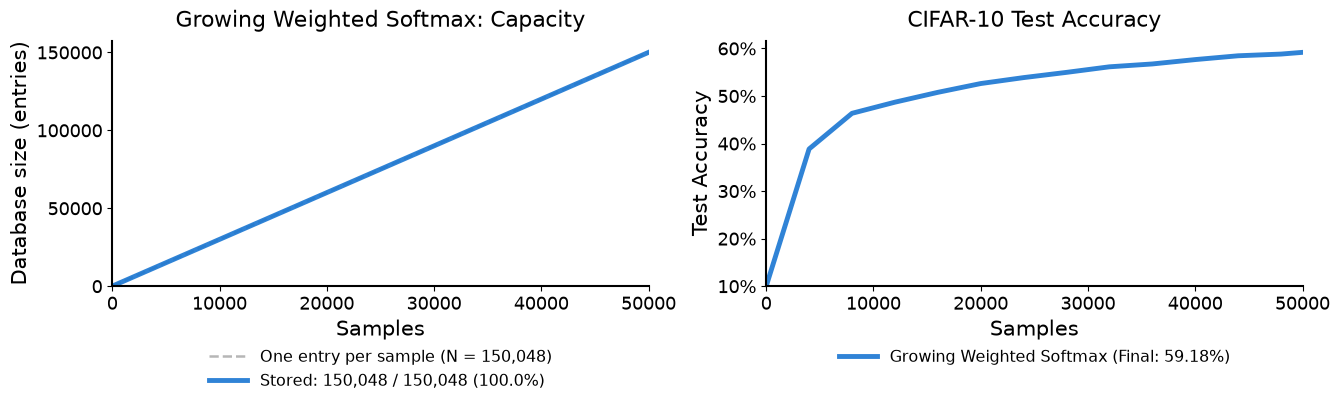

In [5]:
#@title 5.1 Run Growing Weighted Softmax

EVAL_EVERY = 250  # @param {type:"integer"}
FORCE_RETRAIN = False  # @param {type:"boolean"}

gws_cfg = RCDLConfig(
    kernel_type='gws',
    hidden_dim=3072,
    num_layers=2,
    temperature=6.0,               # T
    beta=3.0,                      # β: value learning rate
    model_momentum=0.0,
    db_size=50016,                 # 50,000 (1 epoch) + 16 (init batch)
    num_classes=10,
    batch_size=16,
    eta=0.003,                     # η: weight learning rate
    learning_rate=3e-4,
    num_epochs=1,
    global_init_seed=1,
)

if FORCE_RETRAIN or 'gws_result' not in globals() or gws_result is None or gws_result.get('cfg') != gws_cfg:
  gws_result = run_rcdl_experiment(gws_cfg, eval_every=EVAL_EVERY, keep_model=True)  # model kept for Section 11
_ = plot_rcdl_result(gws_result)

## 5B. Experiment 1B: Gauge-Invariant Weighted Softmax

The weighted softmax has an exact shift (gauge) symmetry: shifting every stored weighted value by $\tilde{\mathbf{v}}_j \leftarrow \tilde{\mathbf{v}}_j + w_j \boldsymbol{\xi}$ shifts the output by $s_D(\mathbf{q}) \leftarrow s_D(\mathbf{q}) + \boldsymbol{\xi}$. The **Gauge-Invariant Weighted Softmax** uses this symmetry to choose a virtual gauge at every step so that the new weight is strictly positive, so no clipping is needed. We use the variant with updates in the order of the gradient length, with gauge parameter $\alpha$:

$$\mathbf{k}_t = \mathbf{q}_t, \qquad w_t = \eta\, \alpha\, \lVert \bar g_t \rVert_2, \qquad \tilde{\mathbf{v}}_t = \left(-\eta \alpha^2 - \beta + \eta\, \alpha\, \frac{\langle s_{t-1}, \bar g_t \rangle}{\lVert \bar g_t \rVert_2 + 10^{-8}}\right) \bar g_t .$$

Note that this implementation uses the batch-mean gradient $\bar g_t = g_t / B$ (see Section 4). Both updates are linear in the gradient, so this is equivalent to the per-sample rule (with $g_t$) using learning rates $\eta / B$ and $\beta / B$.

Gauge-Invariant Weighted Softmax | L=2 residual blocks (+ readout) | hidden=3072 | db_size=50,016
T=5.0 α=10.0 η=0.03 β=100.0 batch=16 seed=1
database ~3.07 GB of float32 parameters


Initial Eval: Loss=6.6232, Accuracy=0.1000, Capacity=48/150,048 (0.0%)


Epoch 1/1:   0%|          | 0/3125 [00:00<?, ?it/s]

Eval at 4,000 samples: Loss=1.7390, Accuracy=0.4017, Capacity=12,048/150,048 (8.0%)


Eval at 8,000 samples: Loss=1.5481, Accuracy=0.4675, Capacity=24,048/150,048 (16.0%)


...

Eval at 36,000 samples: Loss=1.2547, Accuracy=0.5614, Capacity=108,048/150,048 (72.0%)


Eval at 40,000 samples: Loss=1.2397, Accuracy=0.5685, Capacity=120,048/150,048 (80.0%)


Eval at 44,000 samples: Loss=1.2197, Accuracy=0.5787, Capacity=132,048/150,048 (88.0%)


Eval at 48,000 samples: Loss=1.2064, Accuracy=0.5831, Capacity=144,048/150,048 (96.0%)


Eval at 50,000 samples: Loss=1.2028, Accuracy=0.5833, Capacity=150,048/150,048 (100.0%)

--> Finished in 19.8s | Final Test Accuracy: 58.33%
    Total Capacity: 150,048 / 150,048 entries (100.00% of full capacity)



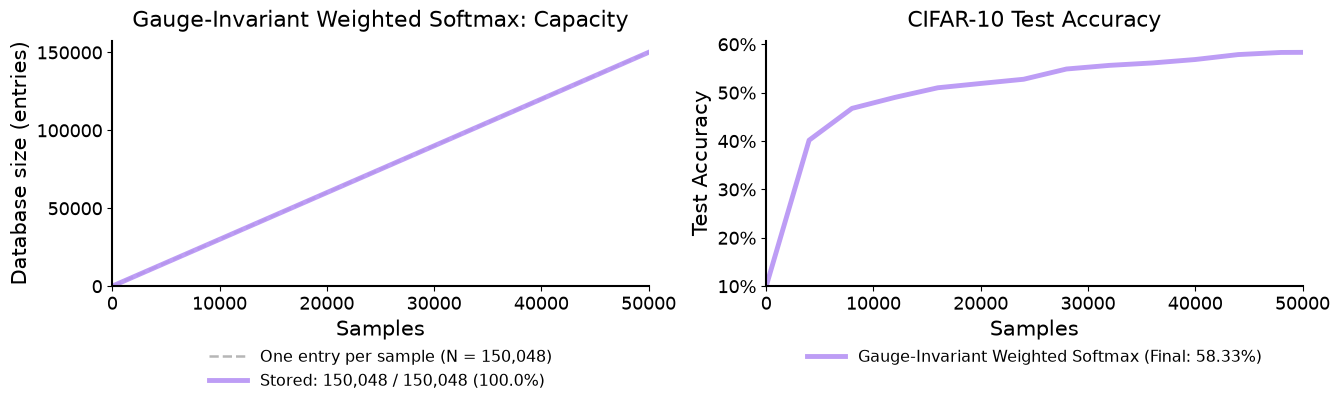

In [6]:
#@title 5.2 Run Gauge-Invariant Weighted Softmax

EVAL_EVERY = 250  # @param {type:"integer"}
FORCE_RETRAIN = False  # @param {type:"boolean"}

gauge_cfg = RCDLConfig(
    kernel_type='gauge',
    gauge_alpha=10.0,              # α: gauge parameter
    eta=0.03,                      # η: weight learning rate
    beta=100.0,                    # β: value learning rate
    hidden_dim=3072,
    num_layers=2,
    temperature=5.0,               # T
    model_momentum=0.0,
    db_size=50016,                 # 50,000 (1 epoch) + 16 (init batch)
    num_classes=10,
    batch_size=16,
    learning_rate=3e-4,
    num_epochs=1,
    global_init_seed=1,
)

if FORCE_RETRAIN or 'gauge_result' not in globals() or gauge_result is None or gauge_result.get('cfg') != gauge_cfg:
  gauge_result = run_rcdl_experiment(gauge_cfg, eval_every=EVAL_EVERY)
_ = plot_rcdl_result(gauge_result)

## 6. Experiment 2: Growing RBF

As a positive-definite kernel (PDK) instance of RCDL, the **Growing RBF** replaces the normalized weighted softmax attention with the unnormalized Gaussian RBF kernel from Section 3. Its learning rule stores the query as the key and the scaled negative gradient as the value:

$$\mathbf{k}_t = \mathbf{q}_t, \qquad \mathbf{v}_t = -\eta\, g_t,$$

where $\eta$ is the value learning rate.

Growing RBF (T=10) | L=2 residual blocks (+ readout) | hidden=3072 | db_size=50,000
T=10.0 η=10.0 init_pred_scale=20.0 momentum=0.0 batch=16 seed=1
database ~3.07 GB of float32 parameters


Initial Eval: Loss=2.3026, Accuracy=0.1000, Capacity=0/150,000 (0.0%)


Epoch 1/1:   0%|          | 0/3125 [00:00<?, ?it/s]

Eval at 4,000 samples: Loss=1.7151, Accuracy=0.4289, Capacity=12,000/150,000 (8.0%)


Eval at 8,000 samples: Loss=1.6107, Accuracy=0.4620, Capacity=24,000/150,000 (16.0%)


...

Eval at 36,000 samples: Loss=1.2784, Accuracy=0.5620, Capacity=108,000/150,000 (72.0%)


Eval at 40,000 samples: Loss=1.2472, Accuracy=0.5752, Capacity=120,000/150,000 (80.0%)


Eval at 44,000 samples: Loss=1.2308, Accuracy=0.5797, Capacity=132,000/150,000 (88.0%)


Eval at 48,000 samples: Loss=1.2110, Accuracy=0.5851, Capacity=144,000/150,000 (96.0%)


Eval at 50,000 samples: Loss=1.1998, Accuracy=0.5842, Capacity=150,000/150,000 (100.0%)

--> Finished in 20.6s | Final Test Accuracy: 58.42%
    Total Capacity: 150,000 / 150,000 entries (100.00% of full capacity)



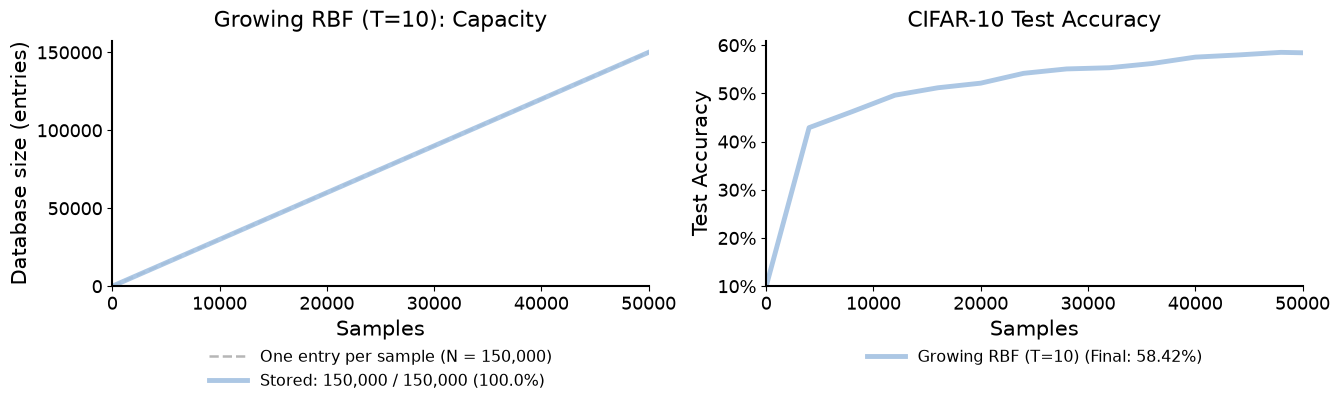

In [7]:
#@title 6.1 Run Growing RBF

TEMPERATURE = 10.0  # @param {type:"number"}
ETA = 10.0  # @param {type:"number"}
BATCH_SIZE = 16  # @param {type:"integer"}
ADD_ACTIVATIONS = False  # @param {type:"boolean"}
FREEZE_INIT_OUT = True  # @param {type:"boolean"}
EVAL_EVERY = 250  # @param {type:"integer"}
FORCE_RETRAIN = False  # @param {type:"boolean"}

rbf_cfg = RCDLConfig(
    kernel_type='rbf',
    hidden_dim=3072,
    num_layers=2,
    temperature=float(TEMPERATURE),  # T: kernel exp(-||q-k||^2 / (2 T sqrt(d_in)))
    init_pred_scale=20.0,
    add_activations=bool(ADD_ACTIVATIONS),
    freeze_init_out=bool(FREEZE_INIT_OUT),
    model_momentum=0.0,
    db_size=(50000 // int(BATCH_SIZE)) * int(BATCH_SIZE),  # 1 epoch (no initial entries)
    num_classes=10,
    batch_size=int(BATCH_SIZE),
    eta=float(ETA),                  # η: value learning rate
    learning_rate=3e-4,
    num_epochs=1,
    global_init_seed=1,
)

if FORCE_RETRAIN or 'rbf_result' not in globals() or rbf_result is None or rbf_result.get('cfg') != rbf_cfg:
  rbf_result = run_rcdl_experiment(rbf_cfg, eval_every=EVAL_EVERY)
_ = plot_rcdl_result(rbf_result)

## 7. Experiment 3: Hybrid Growing Weighted Softmax (Sublinear Growth)

Rather than storing every training sample, the **Hybrid Growing Weighted Softmax** grows its database selectively and refines existing entries by backpropagation:
- **Select novel queries:** A query $\mathbf{q}_{t,n}$ from the current batch is added to the database (with the weight and weighted value of the Growing Weighted Softmax rule from Section 5) only if its Euclidean distance to all stored keys exceeds the growth threshold $\tau$, i.e. $\min_j \lVert \mathbf{q}_{t,n} - \mathbf{k}_j \rVert_2 > \tau$.
- **Parametric update:** All stored keys, weighted values, and weights are updated jointly with one Adam step per batch.

Hybrid Growing Weighted Softmax (τ=50) | L=3 residual blocks (+ readout) | hidden=3072 | db_size=50,016
T=5.0 τ=50.0 η=1.0 β=30.0 Adam lr=0.001 batch=16 seed=42
database ~4.30 GB of float32 parameters


Initial Eval: Loss=6.9345, Accuracy=0.1027, Capacity=64/200,064 (0.0%)


Epoch 1/1:   0%|          | 0/3125 [00:00<?, ?it/s]

Eval at 4,000 samples: Loss=1.7886, Accuracy=0.3844, Capacity=8,158/200,064 (4.1%)


Eval at 8,000 samples: Loss=1.6249, Accuracy=0.4469, Capacity=15,438/200,064 (7.7%)


...

Eval at 36,000 samples: Loss=1.3248, Accuracy=0.5377, Capacity=67,550/200,064 (33.8%)


Eval at 40,000 samples: Loss=1.2880, Accuracy=0.5486, Capacity=75,353/200,064 (37.7%)


Eval at 44,000 samples: Loss=1.3012, Accuracy=0.5450, Capacity=83,050/200,064 (41.5%)


Eval at 48,000 samples: Loss=1.5256, Accuracy=0.5170, Capacity=90,147/200,064 (45.1%)


Eval at 50,000 samples: Loss=1.3298, Accuracy=0.5512, Capacity=93,339/200,064 (46.7%)

--> Finished in 108.5s | Final Test Accuracy: 55.12%
    Total Capacity: 93,339 / 200,064 entries (46.65% of full capacity)



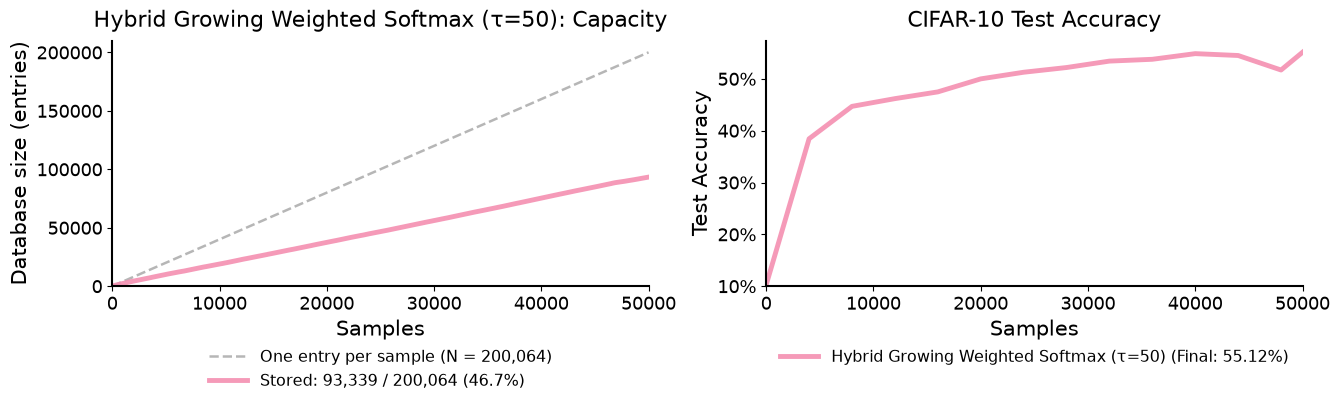

In [8]:
#@title 7.1 Run Hybrid Growing Weighted Softmax

EVAL_EVERY = 250  # @param {type:"integer"}
FORCE_RETRAIN = False  # @param {type:"boolean"}
GROWTH_THRESHOLD = 50.0        # @param {type:"number"}

hybrid_cfg = RCDLConfig(
    kernel_type='hybrid',
    hidden_dim=3072,
    num_layers=3,
    temperature=5.0,               # T
    db_size=50016,                 # 50,000 (1 epoch) + 16 (init batch)
    growth_threshold=GROWTH_THRESHOLD,
    beta=30.0,                     # β: value learning rate
    num_classes=10,
    batch_size=16,
    eta=1.0,                       # η: weight learning rate
    learning_rate=1e-3,            # Adam learning rate (parametric refinement)
    num_epochs=1,
    global_init_seed=42,
)

if FORCE_RETRAIN or 'hybrid_result' not in globals() or hybrid_result is None or hybrid_result.get('cfg') != hybrid_cfg:
  hybrid_result = run_rcdl_experiment(hybrid_cfg, eval_every=EVAL_EVERY)
_ = plot_rcdl_result(hybrid_result)

## 8. Experiment 4: ResNet-MLP Baseline

As a standard deep learning reference, the **ResNet-MLP** replaces all RCDL layers with standard learnable `nn.Linear` + `GELU` residual blocks. Select the optimizer (`adam`, `sgd`, `adamw`, `rmsprop`, or `muon`) using the form controls below. By default (`USE_TUNED_HPARAMS`), each optimizer uses its best hyperparameters:

Uncheck `USE_TUNED_HPARAMS` to set the learning rate, momentum, and weight decay manually.

ResNet-MLP | optimizer=adam (tuned) | lr=0.0001 | B=16 | momentum=0 | weight_decay=0


ResNet-MLP (8L GELU, ADAM) | L=8 residual blocks (+ readout) | hidden=3072 | activation='gelu'
optimizer=adam lr=0.0001 momentum=0.0 weight_decay=0.0 batch=16 seed=1
dense parameters ~0.30 GB of float32 weights (fixed layer width=3,072 = 6.1% cap)
Initial Eval: Loss=2.8912, Accuracy=0.1047, Capacity=24,576/400,128 (6.1%)


Epoch 1/1:   0%|          | 0/3125 [00:00<?, ?it/s]

Eval at 4,000 samples: Loss=1.7869, Accuracy=0.3708, Capacity=24,576/400,128 (6.1%)


Eval at 8,000 samples: Loss=1.8236, Accuracy=0.3669, Capacity=24,576/400,128 (6.1%)


...

Eval at 36,000 samples: Loss=1.4633, Accuracy=0.4813, Capacity=24,576/400,128 (6.1%)


Eval at 40,000 samples: Loss=1.4344, Accuracy=0.4901, Capacity=24,576/400,128 (6.1%)


Eval at 44,000 samples: Loss=1.4291, Accuracy=0.4932, Capacity=24,576/400,128 (6.1%)


Eval at 48,000 samples: Loss=1.4296, Accuracy=0.4921, Capacity=24,576/400,128 (6.1%)


Eval at 50,000 samples: Loss=1.4085, Accuracy=0.4969, Capacity=24,576/400,128 (6.1%)

--> Finished in 13.3s | Final Test Accuracy: 49.69%
    Total Capacity: 24,576 / 400,128 entries (6.14% of full capacity)



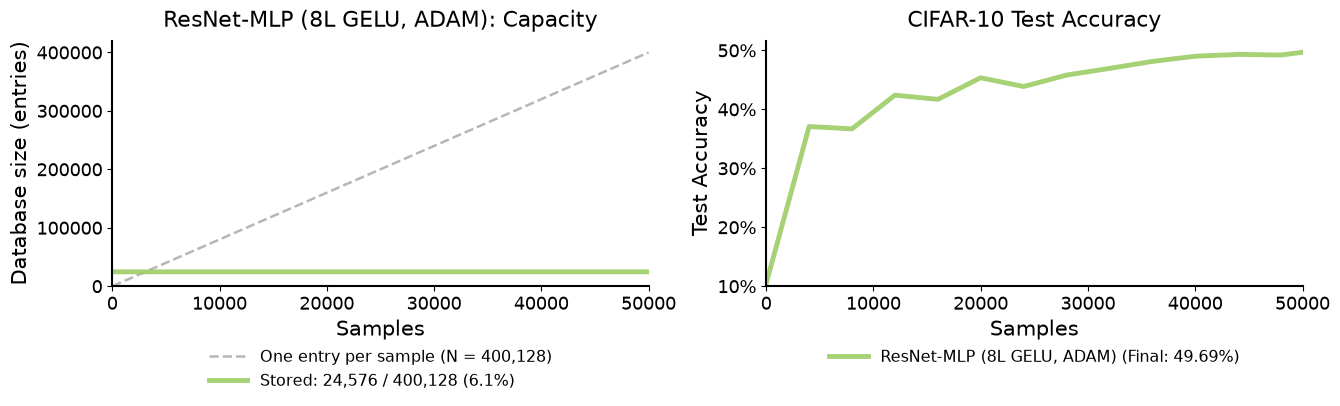

In [9]:
#@title 8.1 Run ResNet-MLP

OPTIMIZER = "adam"  # @param ["adam", "sgd", "adamw", "rmsprop", "muon"]
USE_TUNED_HPARAMS = True  # @param {type:"boolean"}
#@markdown Manual settings below are only used if `USE_TUNED_HPARAMS` is unchecked.
LEARNING_RATE = 1e-4  # @param {type:"number"}
MOMENTUM = 0.85  # @param {type:"number"}
WEIGHT_DECAY = 0.0  # @param {type:"number"}
EVAL_EVERY = 250  # @param {type:"integer"}
FORCE_RETRAIN = False  # @param {type:"boolean"}
BATCH_SIZE = 16

# Best hyperparameters per optimizer at batch size 16 for this ResNet-MLP
TUNED_HPARAMS = {
    'adam':    dict(learning_rate=1e-4, momentum=0.0,  weight_decay=0.0),   # 48.2 ± 1.0 %
    'adamw':   dict(learning_rate=1e-4, momentum=0.0,  weight_decay=1e-4),  # 48.3 ± 1.0 %
    'muon':    dict(learning_rate=1e-3, momentum=0.0,  weight_decay=0.0),   # 57.2 ± 0.4 %
    'rmsprop': dict(learning_rate=1e-4, momentum=0.0,  weight_decay=0.0),   # 49.9 ± 0.7 %
    'sgd':     dict(learning_rate=1e-3, momentum=0.85, weight_decay=0.0),   # 46.3 ± 2.0 %
}

if USE_TUNED_HPARAMS:
  hp = TUNED_HPARAMS[OPTIMIZER]
else:
  hp = dict(learning_rate=LEARNING_RATE, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
print(f"ResNet-MLP | optimizer={OPTIMIZER} ({'tuned' if USE_TUNED_HPARAMS else 'manual'}) | "
      f"lr={hp['learning_rate']:g} | B={BATCH_SIZE} | "
      f"momentum={hp['momentum'] if OPTIMIZER == 'sgd' else 0.0:g} | "
      f"weight_decay={hp['weight_decay'] if OPTIMIZER in ('adamw', 'muon') else 0.0:g}")

standard_cfg = RCDLConfig(
    kernel_type='standard',
    hidden_dim=3072,
    num_layers=8,
    nonlinearity='gelu',
    use_residual=True,
    num_classes=10,
    batch_size=int(BATCH_SIZE),
    optimizer=OPTIMIZER,
    learning_rate=float(hp['learning_rate']),
    model_momentum=float(hp['momentum']) if OPTIMIZER == 'sgd' else 0.0,
    weight_decay=float(hp['weight_decay']) if OPTIMIZER in ('adamw', 'muon') else 0.0,
    num_epochs=1,
    global_init_seed=1,
)

if FORCE_RETRAIN or 'standard_result' not in globals() or standard_result is None or standard_result.get('cfg') != standard_cfg:
  standard_result = run_rcdl_experiment(standard_cfg, eval_every=EVAL_EVERY)
_ = plot_rcdl_result(standard_result)

## 9. Experiment 5: Parametric Softmax Baseline (10% vs. 100% Capacity)

To isolate the role of the **nonparametric growth rule** from the weighted softmax architecture itself, the **Parametric Softmax** pre-allocates a fixed-size table of $N$ entries per layer at initialization and trains all $(w_j, \mathbf{k}_j, \tilde{\mathbf{v}}_j)$ purely by backpropagation with Adam (no database growth). We evaluate two table sizes:
1. **10% Capacity** ($N = 5{,}000$; an additional ablation that is not part of the paper)
2. **100% Capacity** ($N = 50{,}016$, the final database size of the Growing Weighted Softmax)

>>> Running Parametric Softmax at 10% Capacity (5,000 entries) <<<


Parametric Softmax (10% Cap) | L=2 residual blocks (+ readout) | hidden=3072 | db_size=5,000
T=3.0 optimizer=adam lr=0.001 learn_weights=True batch=16 seed=1
database ~0.31 GB of float32 parameters
Initial Eval: Loss=2.3026, Accuracy=0.1000, Capacity=15,000/150,048 (10.0%)


Epoch 1/1:   0%|          | 0/3125 [00:00<?, ?it/s]

Eval at 4,000 samples: Loss=2.2982, Accuracy=0.1510, Capacity=15,000/150,048 (10.0%)


Eval at 8,000 samples: Loss=2.1628, Accuracy=0.1989, Capacity=15,000/150,048 (10.0%)


...

Eval at 36,000 samples: Loss=1.7382, Accuracy=0.3788, Capacity=150,048/150,048 (100.0%)


Eval at 40,000 samples: Loss=1.7163, Accuracy=0.3854, Capacity=150,048/150,048 (100.0%)


Eval at 44,000 samples: Loss=1.6942, Accuracy=0.3934, Capacity=150,048/150,048 (100.0%)


Eval at 48,000 samples: Loss=1.6819, Accuracy=0.4014, Capacity=150,048/150,048 (100.0%)


Eval at 50,000 samples: Loss=1.6715, Accuracy=0.4060, Capacity=150,048/150,048 (100.0%)

--> Finished in 67.2s | Final Test Accuracy: 40.60%
    Total Capacity: 150,048 / 150,048 entries (100.00% of full capacity)



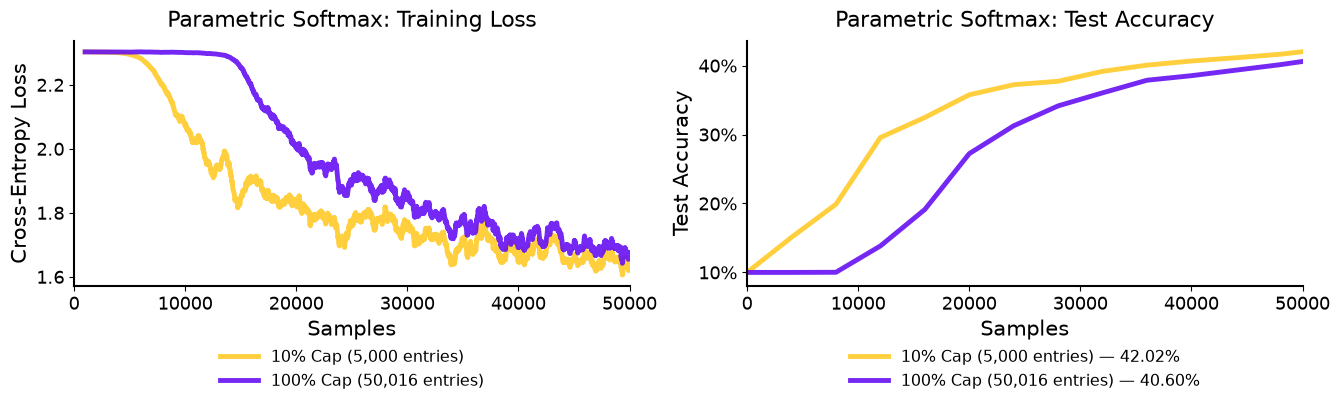

In [10]:
#@title 9.1 Run Parametric Softmax Baseline (10% and 100% Capacity)

BATCH_SIZE = 16  # @param {type:"integer"}
EVAL_EVERY = 250  # @param {type:"integer"}
FORCE_RETRAIN = False  # @param {type:"boolean"}


def parametric_softmax_config(db_size: int) -> RCDLConfig:
  return RCDLConfig(
      kernel_type='parametric_softmax',
      hidden_dim=3072,
      num_layers=2,
      temperature=3.0,
      db_size=db_size,               # N entries per layer
      full_epoch_capacity=50016,
      learn_parametric_weights=True,
      num_classes=10,
      batch_size=int(BATCH_SIZE),
      optimizer='adam',
      learning_rate=1e-3,
      num_epochs=1,
      global_init_seed=1,
  )


# 1. Parametric Softmax at 10% Capacity (5,000 entries)
parametric_softmax_10pct_cfg = parametric_softmax_config(5000)
if (
    FORCE_RETRAIN
    or 'parametric_softmax_10pct_result' not in globals()
    or parametric_softmax_10pct_result is None
    or parametric_softmax_10pct_result.get('cfg') != parametric_softmax_10pct_cfg
):
  print(">>> Running Parametric Softmax at 10% Capacity (5,000 entries) <<<")
  parametric_softmax_10pct_result = run_rcdl_experiment(parametric_softmax_10pct_cfg, eval_every=EVAL_EVERY)

# 2. Parametric Softmax at 100% Capacity (50,016 entries)
parametric_softmax_100pct_cfg = parametric_softmax_config(50016)
if (
    FORCE_RETRAIN
    or 'parametric_softmax_100pct_result' not in globals()
    or parametric_softmax_100pct_result is None
    or parametric_softmax_100pct_result.get('cfg') != parametric_softmax_100pct_cfg
):
  print(">>> Running Parametric Softmax at 100% Capacity (50,016 entries) <<<")
  parametric_softmax_100pct_result = run_rcdl_experiment(parametric_softmax_100pct_cfg, eval_every=EVAL_EVERY)


def plot_parametric_softmax_comparison(res_10: Dict[str, Any], res_100: Dict[str, Any]):
  """Compares Parametric Softmax at 10% (5,000 entries) vs 100% (50,016 entries) capacity in the paper style."""
  h10, h100 = res_10['history'], res_100['history']
  fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(13.5, 5.2))

  col_10, col_100 = '#ffca28', '#6610f2'
  for h, col, lbl in [(h10, col_10, '10% Cap (5,000 entries)'), (h100, col_100, '100% Cap (50,016 entries)')]:
    s_arr, l_arr = np.asarray(h['samples']), np.asarray(h['train_losses'])
    win = max(1, len(l_arr) // 50)
    ax_loss.plot(s_arr[win - 1:], np.convolve(l_arr, np.ones(win) / float(win), mode='valid'),
                 ls='-', lw=3.5, color=col, alpha=0.9, label=lbl)
  ax_loss.set_title('Parametric Softmax: Training Loss', fontsize=16, pad=10)
  ax_loss.set_xlabel('Samples', fontsize=15)
  ax_loss.set_ylabel('Cross-Entropy Loss', fontsize=15)
  ax_loss.set_xlim(0, 50000)

  t10, a10 = np.asarray(h10['test_samples']), np.asarray(h10['test_accuracies']) * 100.0
  t100, a100 = np.asarray(h100['test_samples']), np.asarray(h100['test_accuracies']) * 100.0
  ax_acc.plot(t10, a10, ls='-', lw=3.5, color=col_10, alpha=0.9, label=f'10% Cap (5,000 entries) — {a10[-1]:.2f}%')
  ax_acc.plot(t100, a100, ls='-', lw=3.5, color=col_100, alpha=0.9, label=f'100% Cap (50,016 entries) — {a100[-1]:.2f}%')
  ax_acc.set_title('Parametric Softmax: Test Accuracy', fontsize=16, pad=10)
  ax_acc.set_xlabel('Samples', fontsize=15)
  ax_acc.set_ylabel('Test Accuracy', fontsize=15)
  ax_acc.set_xlim(0, 50000)
  ax_acc.set_ylim(8.0, None)
  ax_acc.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100.0, decimals=0))

  for ax in (ax_loss, ax_acc):
    style_paper_ax(ax)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.20), frameon=False, fontsize=11.5, handlelength=2.4)
  plt.tight_layout(rect=[0.0, 0.14, 1.0, 1.0])
  plt.show()
  return fig


_ = plot_parametric_softmax_comparison(parametric_softmax_10pct_result, parametric_softmax_100pct_result)

## 10. Benchmark Comparison Across All Models

Run the cell below to compare **Training Loss**, **CIFAR-10 Test Accuracy**, and **Capacity** (number of stored database entries) across all models executed above.

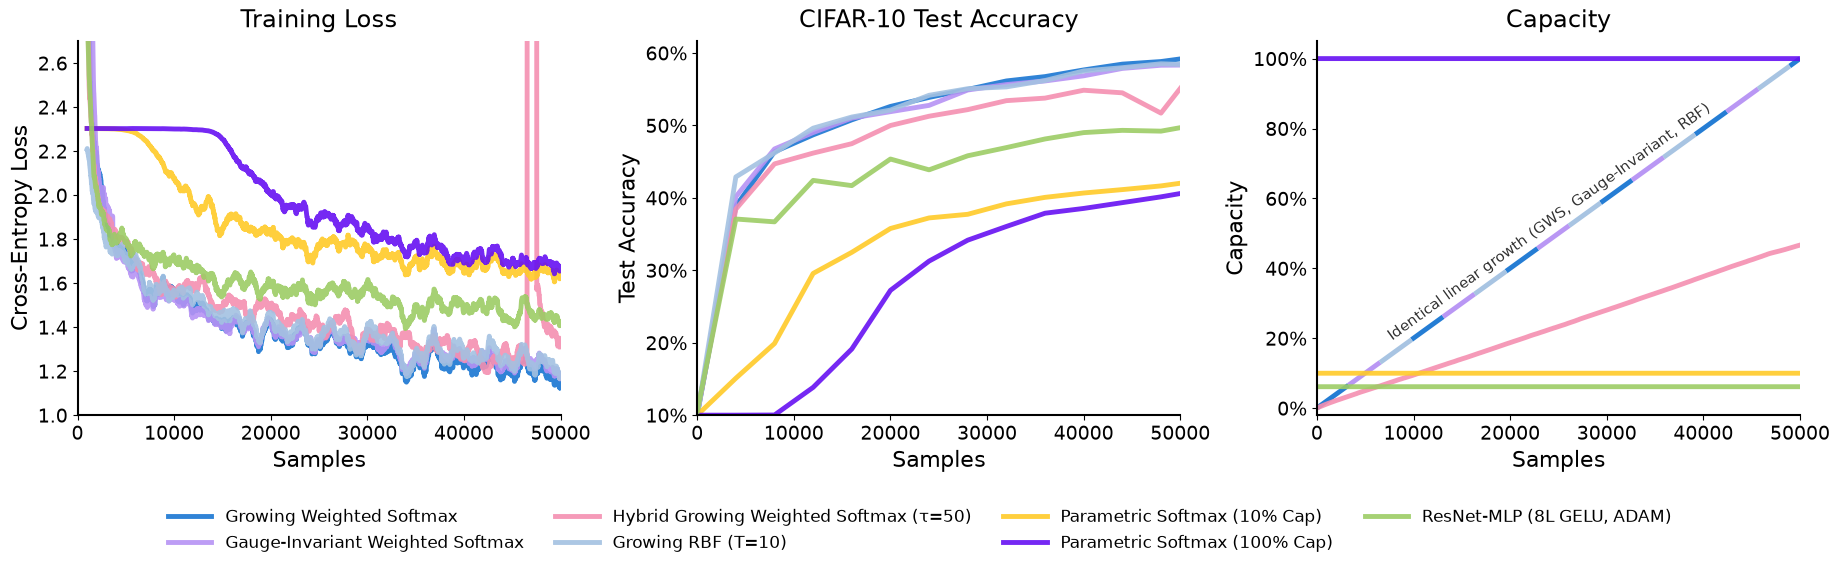

In [11]:
#@title 10.1 Plot Master Benchmark Comparison

def plot_all_rcdl_models(results_map: Dict[str, Optional[Dict[str, Any]]]):
  """3-panel comparison of Training Loss, Test Accuracy, and Active Capacity in the paper style."""
  fontsize_title, fontsize_labels, fontsize_ticks, fontsize_legend, linewidth_traj = 17, 16, 14, 12.5, 3.5
  fig, (ax_loss, ax_acc, ax_mem) = plt.subplots(1, 3, figsize=(18.5, 5.8))

  short_linear_names = {'gws': 'GWS', 'gauge': 'Gauge-Invariant', 'rbf': 'RBF'}
  linear_keys = [k for k in short_linear_names if results_map.get(k) is not None]
  legend_handles, legend_labels = [], []

  for key, res in results_map.items():
    if res is None:
      continue
    h = res['history']
    col, label = method_style(res['cfg'])
    samples, ts = np.asarray(h['samples']), np.asarray(h['test_samples'])
    acc, losses = np.asarray(h['test_accuracies']) * 100.0, np.asarray(h['train_losses'])

    win = max(1, len(losses) // 50)   # smooth the training loss with a moving window
    ax_loss.plot(samples[win - 1:], np.convolve(losses, np.ones(win) / float(win), mode='valid'),
                 ls='-', lw=linewidth_traj, color=col, alpha=0.9)
    line_handle, = ax_acc.plot(ts, acc, ls='-', lw=linewidth_traj, color=col, alpha=0.9, label=label)
    legend_handles.append(line_handle)
    legend_labels.append(label)

    # Overall active capacity = sum of stored entries across all layers, in % of the full 1-epoch capacity
    total_active = np.sum([np.asarray(v, dtype=np.float64) for v in h['per_layer_db_sizes'].values()], axis=0)
    pct_active = 100.0 * total_active / float(h['total_full_capacity'])
    if key in linear_keys and len(linear_keys) > 1:   # phased dashes: the linear-growth curves share the diagonal
      n_lin, lin_idx, dash_len = len(linear_keys), linear_keys.index(key), 8
      offset = (-lin_idx * dash_len) % (dash_len * n_lin)
      ax_mem.plot(samples, pct_active, linestyle=(offset, (dash_len, dash_len * (n_lin - 1))),
                  lw=linewidth_traj, color=col, alpha=0.95, dash_capstyle='butt')
    else:
      ax_mem.plot(samples, pct_active, ls='-', lw=linewidth_traj, color=col, alpha=0.9)

  for ax in (ax_loss, ax_acc, ax_mem):
    style_paper_ax(ax, fontsize_ticks=fontsize_ticks)
    ax.set_xlim(0, 50000)
    ax.set_xlabel('Samples', fontsize=fontsize_labels)

  ax_loss.set_title('Training Loss', fontsize=fontsize_title, pad=10)
  ax_loss.set_ylabel('Cross-Entropy Loss', fontsize=fontsize_labels)
  ax_loss.set_ylim(1.0, 2.7)

  ax_acc.set_title('CIFAR-10 Test Accuracy', fontsize=fontsize_title, pad=10)
  ax_acc.set_ylabel('Test Accuracy', fontsize=fontsize_labels)
  ax_acc.set_ylim(10.0, None)
  ax_acc.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100.0, decimals=0))

  ax_mem.set_title('Capacity', fontsize=fontsize_title, pad=10)
  ax_mem.set_ylabel('Capacity', fontsize=fontsize_labels)
  ax_mem.set_ylim(-2, 105)
  ax_mem.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100.0, decimals=0))

  plt.tight_layout(rect=[0.0, 0.15, 1.0, 1.0])
  if len(linear_keys) > 1:
    lin_tag = ', '.join(short_linear_names[k] for k in linear_keys)
    ax_mem.text(24500, 51.5, f'Identical linear growth ({lin_tag})', rotation=np.degrees(np.arctan2(100.0, 50000.0)),
                rotation_mode='anchor', transform_rotates_text=True, ha='center', va='bottom', fontsize=10.5, color='#333333')
  if legend_handles:
    fig.legend(legend_handles, legend_labels, loc='upper center', bbox_to_anchor=(0.5, 0.14),
               ncol=min(4, len(legend_handles)), fontsize=fontsize_legend, frameon=False, handlelength=2.5, columnspacing=1.8)
  plt.show()
  return fig


_ = plot_all_rcdl_models({
    'gws': globals().get('gws_result'),
    'gauge': globals().get('gauge_result'),
    'hybrid': globals().get('hybrid_result'),
    'rbf': globals().get('rbf_result'),
    'parametric_softmax_10pct': globals().get('parametric_softmax_10pct_result'),
    'parametric_softmax_100pct': globals().get('parametric_softmax_100pct_result'),
    'standard': globals().get('standard_result'),
})

## 11. Retrieval Analysis of the Best Growing Weighted Softmax: Layer-wise Retrieval, Attribution & Top-$K$ Sparsity

Every database entry of a Growing Weighted Softmax was written by exactly one training image. All layers grow in lockstep (one entry per training image per step), so entry $j$ belongs to the **same** training image $X_j$ in every layer: the $B$ random initial entries $D_0$ come first, followed by the 50,000 training images in the order in which they were streamed. This lets us trace any prediction back to the training images it retrieves, in every layer.

We analyze the best-performing Growing Weighted Softmax ($L=2$ residual blocks, $T=6$, $\beta=3$, $\eta=0.003$, ~59.3% test accuracy). Each layer $l = 0, \dots, L$ attends with its own query
$$\mathbf{q}^{(l)} = \mathrm{RMSNorm}(\mathbf{x}^{(l)}), \qquad \mathbf{x}^{(0)} = \mathbf{x}, \qquad \mathbf{x}^{(l+1)} = \mathbf{x}^{(l)} + s_{D^{(l)}}(\mathbf{q}^{(l)}),$$
where layer $L$ is the 10-class readout. **Attention to $X_j$ in layer $l$** means: the query's layer-$l$ representation resembles that of $X_j$, so the layer retrieves the correction $\tilde{\mathbf{v}}^{(l)}_j = -\beta\, \mathbf{g}^{(l)}_j$ that $X_j$'s loss requested at that layer. We compare the **pure attention** $a_j(\mathbf{q}) = \exp(z_j(\mathbf{q})) / \sum_m \exp(z_m(\mathbf{q}))$, with $z_j(\mathbf{q}) = \langle \mathbf{q}, \mathbf{k}_j \rangle / (T\sqrt{d_{\text{in}}})$, against the effective contributions below.

**Exact attribution at the readout.** The readout's logits $s_D(\mathbf{q}) \in \mathbb{R}^{10}$ decompose into an exact sum of per-entry contributions:
$$s_D(\mathbf{q}) = \sum_{j} \mathbf{c}_j(\mathbf{q}), \qquad \mathbf{c}_j(\mathbf{q}) = \tilde a_j(\mathbf{q})\, \tilde{\mathbf{v}}_j \in \mathbb{R}^{10}, \qquad \tilde a_j(\mathbf{q}) = \frac{\exp(z_j(\mathbf{q}))}{\sum_m w_m \exp(z_m(\mathbf{q}))}.$$
To show which entries help or hurt the prediction, we use the **margin view**: with true label $y$ and rival $r = \arg\max_{c \neq y} s_D(\mathbf{q})[c]$ (the strongest wrong class),
$$m_j(\mathbf{q}) = \mathbf{c}_j(\mathbf{q})[y] - \mathbf{c}_j(\mathbf{q})[r], \qquad \sum_j m_j(\mathbf{q}) = s_D(\mathbf{q})[y] - s_D(\mathbf{q})[r],$$
so the per-entry margins add up to the margin, which is positive if and only if the prediction is correct. Entries with $m_j > 0$ help the true class against its strongest competitor; entries with $m_j < 0$ help the rival.

Three things to keep in mind:
- **Layer 0 is still pixel similarity.** Its query is the RMS-normalized image and its keys are the RMS-normalized training images. Later layers see the residual stream, which still contains the image, so they are not guaranteed to become more semantic; 11.2 measures this.
- **Keys are snapshots.** For $l \ge 1$, the key $\mathbf{k}^{(l)}_j$ is $X_j$'s layer-$l$ representation at the time it was written (computed with the database $D_{t-1}$ of that moment), whereas test queries are computed with the final database.
- **Exact attribution exists only at the readout.** Hidden-layer values are directions in the 3072-d residual stream, so for hidden layers we show attention only.

- **11.1 (Layer-wise Retrieval Explorer)**: Trains (or reuses the Section 5.1 result of) the model and, for each test query, shows the top-$K$ training images by attention $a^{(l)}_j$ in every layer, plus the readout's largest contributions $\lVert \mathbf{c}_j(\mathbf{q}) \rVert_2$ and its top helpers ($m_j > 0$) and hurters ($m_j < 0$). `px#r` is the entry's rank under pure pixel similarity (layer-0 attention). The bottom-left panel shows the resulting logits $s_D(\mathbf{q})[k] = \sum_j \mathbf{c}_j(\mathbf{q})[k]$ of all 10 classes, i.e. what is left after all positive and negative contributions cancel; the highest bar is the prediction. Use `TEST_INDICES` to inspect specific test images.
- **11.2 (Depth Statistics)**: Over all 10,000 test images and for each layer: the same-class purity of the top-$K$ entries, their overlap with the pixel-space top-$K$ (layer 0), and how the attention mass is distributed over write time. Rising purity and falling pixel overlap with depth indicate that retrieval becomes more semantic.
- **11.3 (Top-$K$ Sparsity Sweep)**: Evaluates test-time Top-$K$ pruning, comparing **Top-$K$ by Contribution Magnitude** ($z_j(\mathbf{q}) + \log \lVert \tilde{\mathbf{v}}_j \rVert_2$, i.e. ranking by $\lVert \mathbf{c}_j(\mathbf{q}) \rVert_2$) against **Top-$K$ by Pure Kernel Similarity** ($z_j(\mathbf{q})$):
  1. **1D Equal-Sparsity Curve ($K_{\text{hidden}} = K_{\text{readout}} = K$)**: When all layers are pruned equally along the diagonal, representations at $T=6$ are distributed across many entries, and **Pure Kernel Similarity** preserves accuracy much better than weighting by raw value norms across intermediate layers.
  2. **2D Layer-wise Accuracy Heatmap ($K_{\text{hidden}}$ vs. $K_{\text{readout}}$)**: Decoupling the sparsity of the **hidden feature layers (`layer_0`, `layer_1` on the x-axis)** from the **classifier readout layer (`output_layer` on the y-axis)** reveals *where* each ranking rule succeeds or breaks down across the full $(K_{\text{hidden}}, K_{\text{readout}})$ plane.

Using cached Growing Weighted Softmax, L=2 (T=6, η=0.003, β=3 | Final Test Acc: 59.18%)
Replayed forward pass vs. model: max |Δ logits| = 2.67e-05
Verified entry alignment (layer_0 entries 16.. <-> train_images[deep_perm]): max |key - RMSNorm(img)| = 0.00e+00


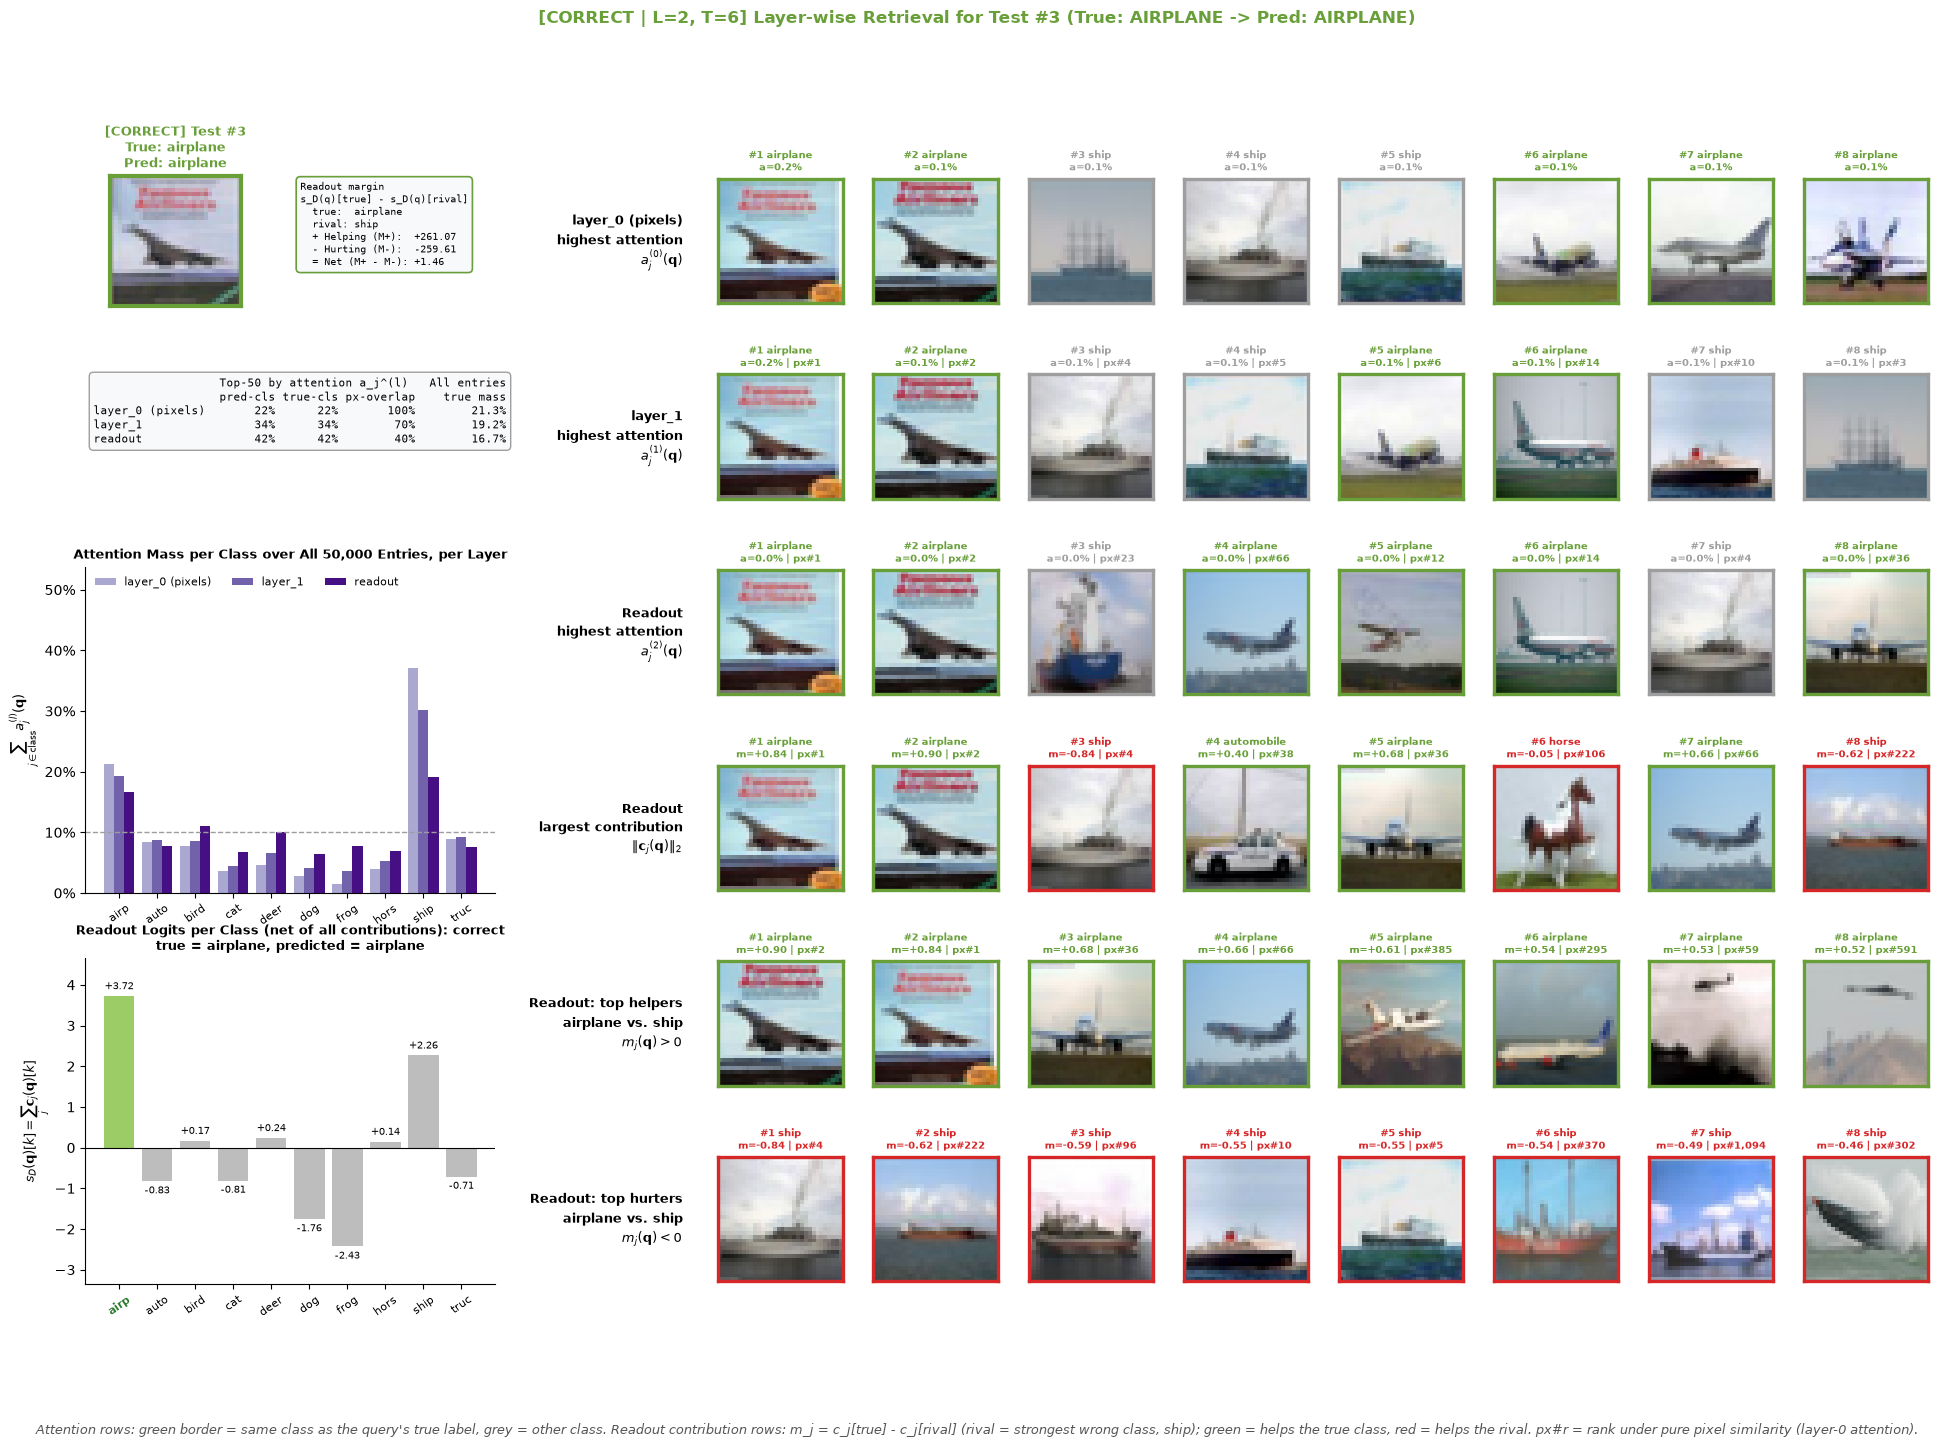

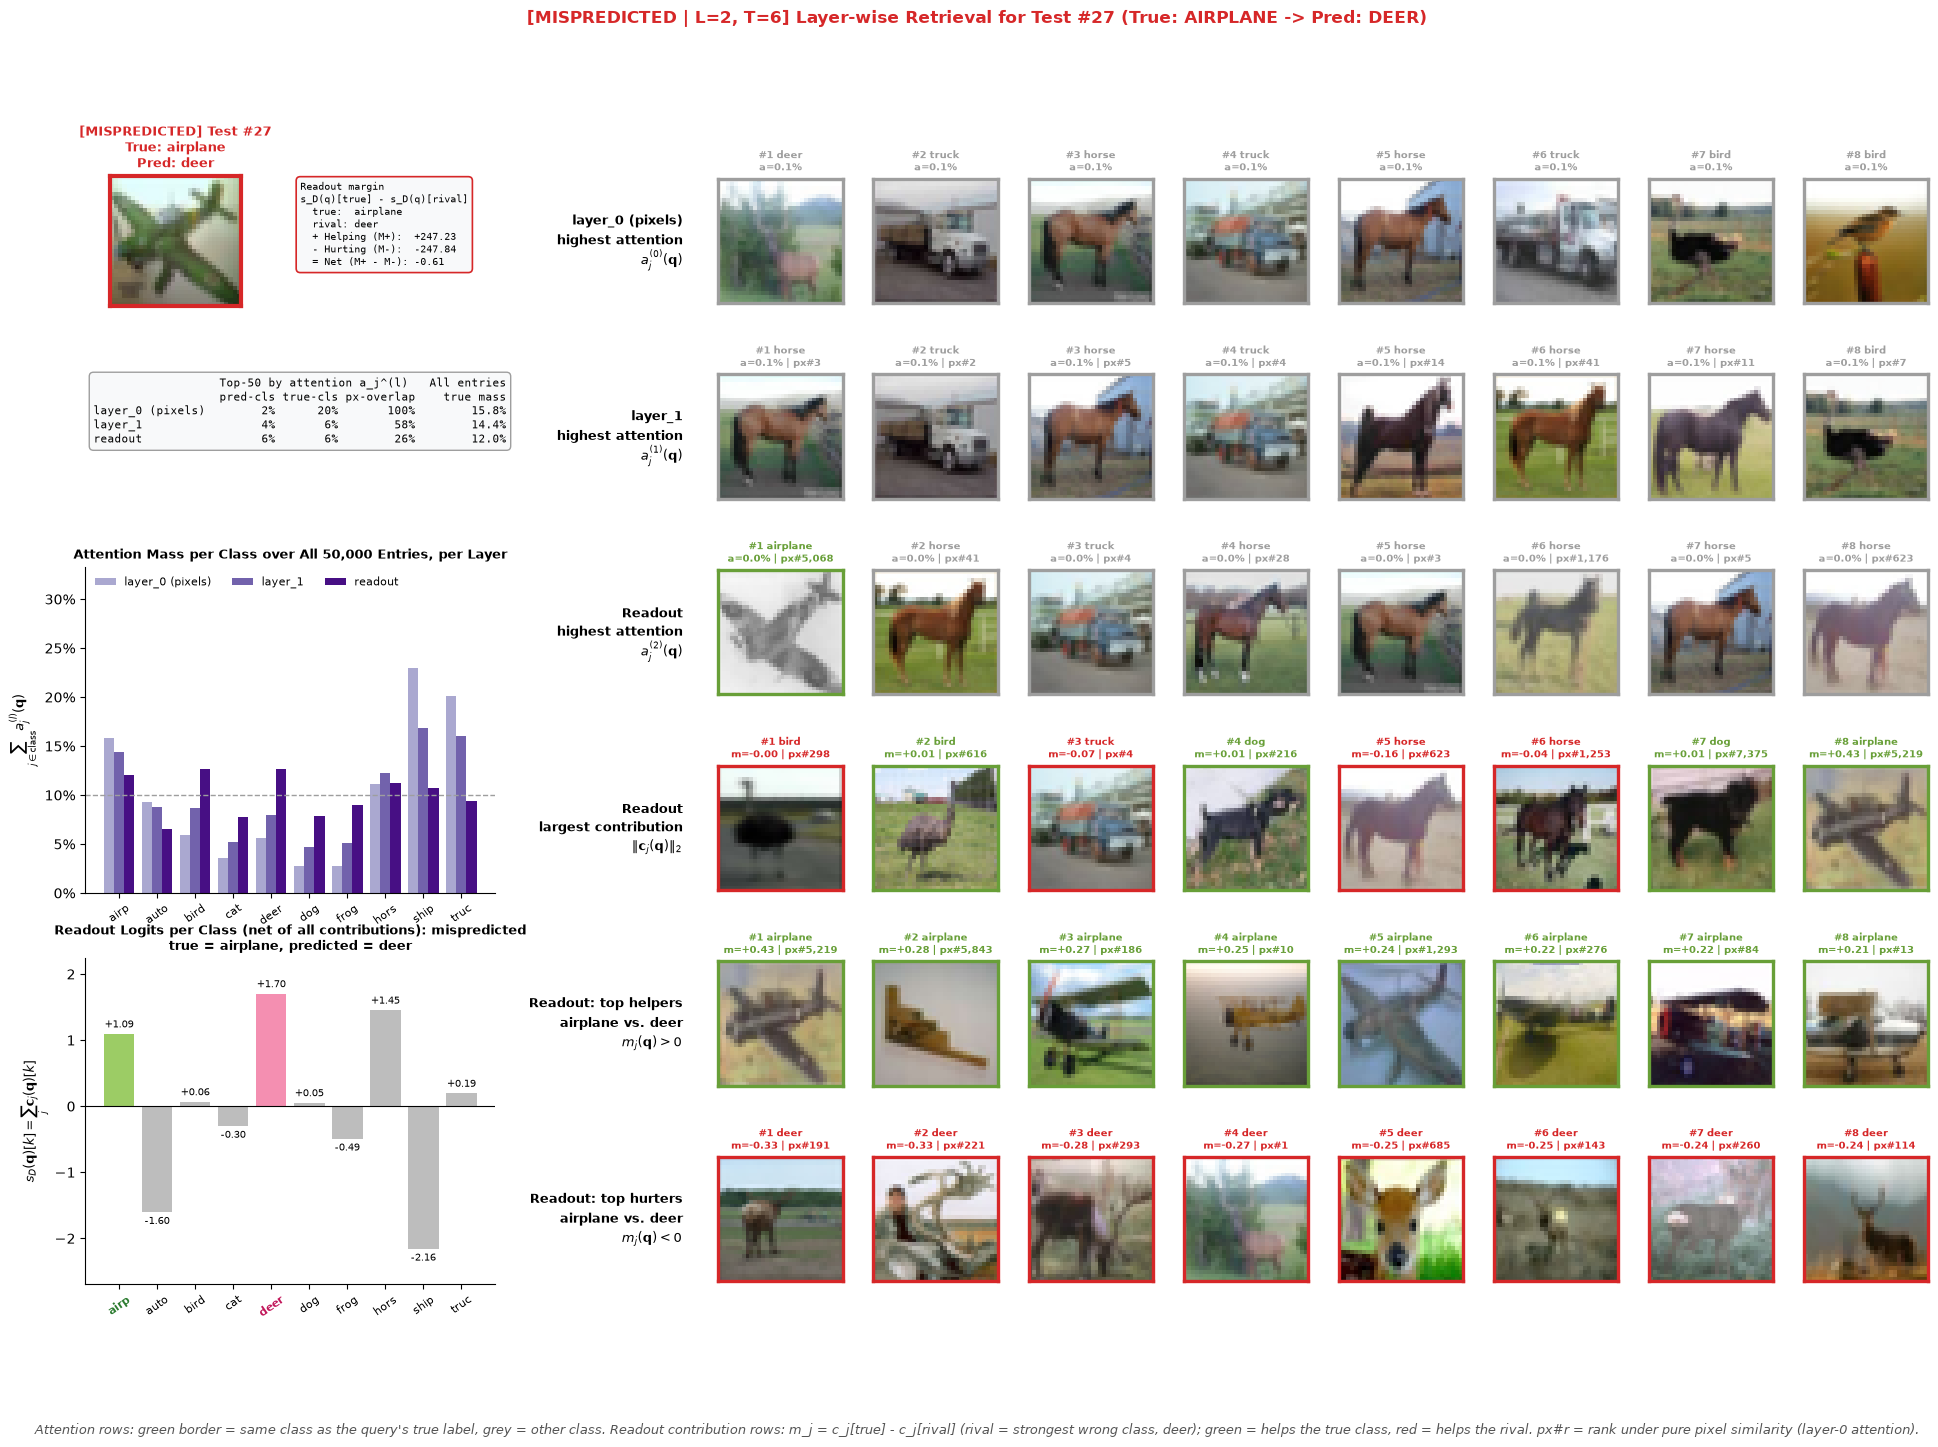

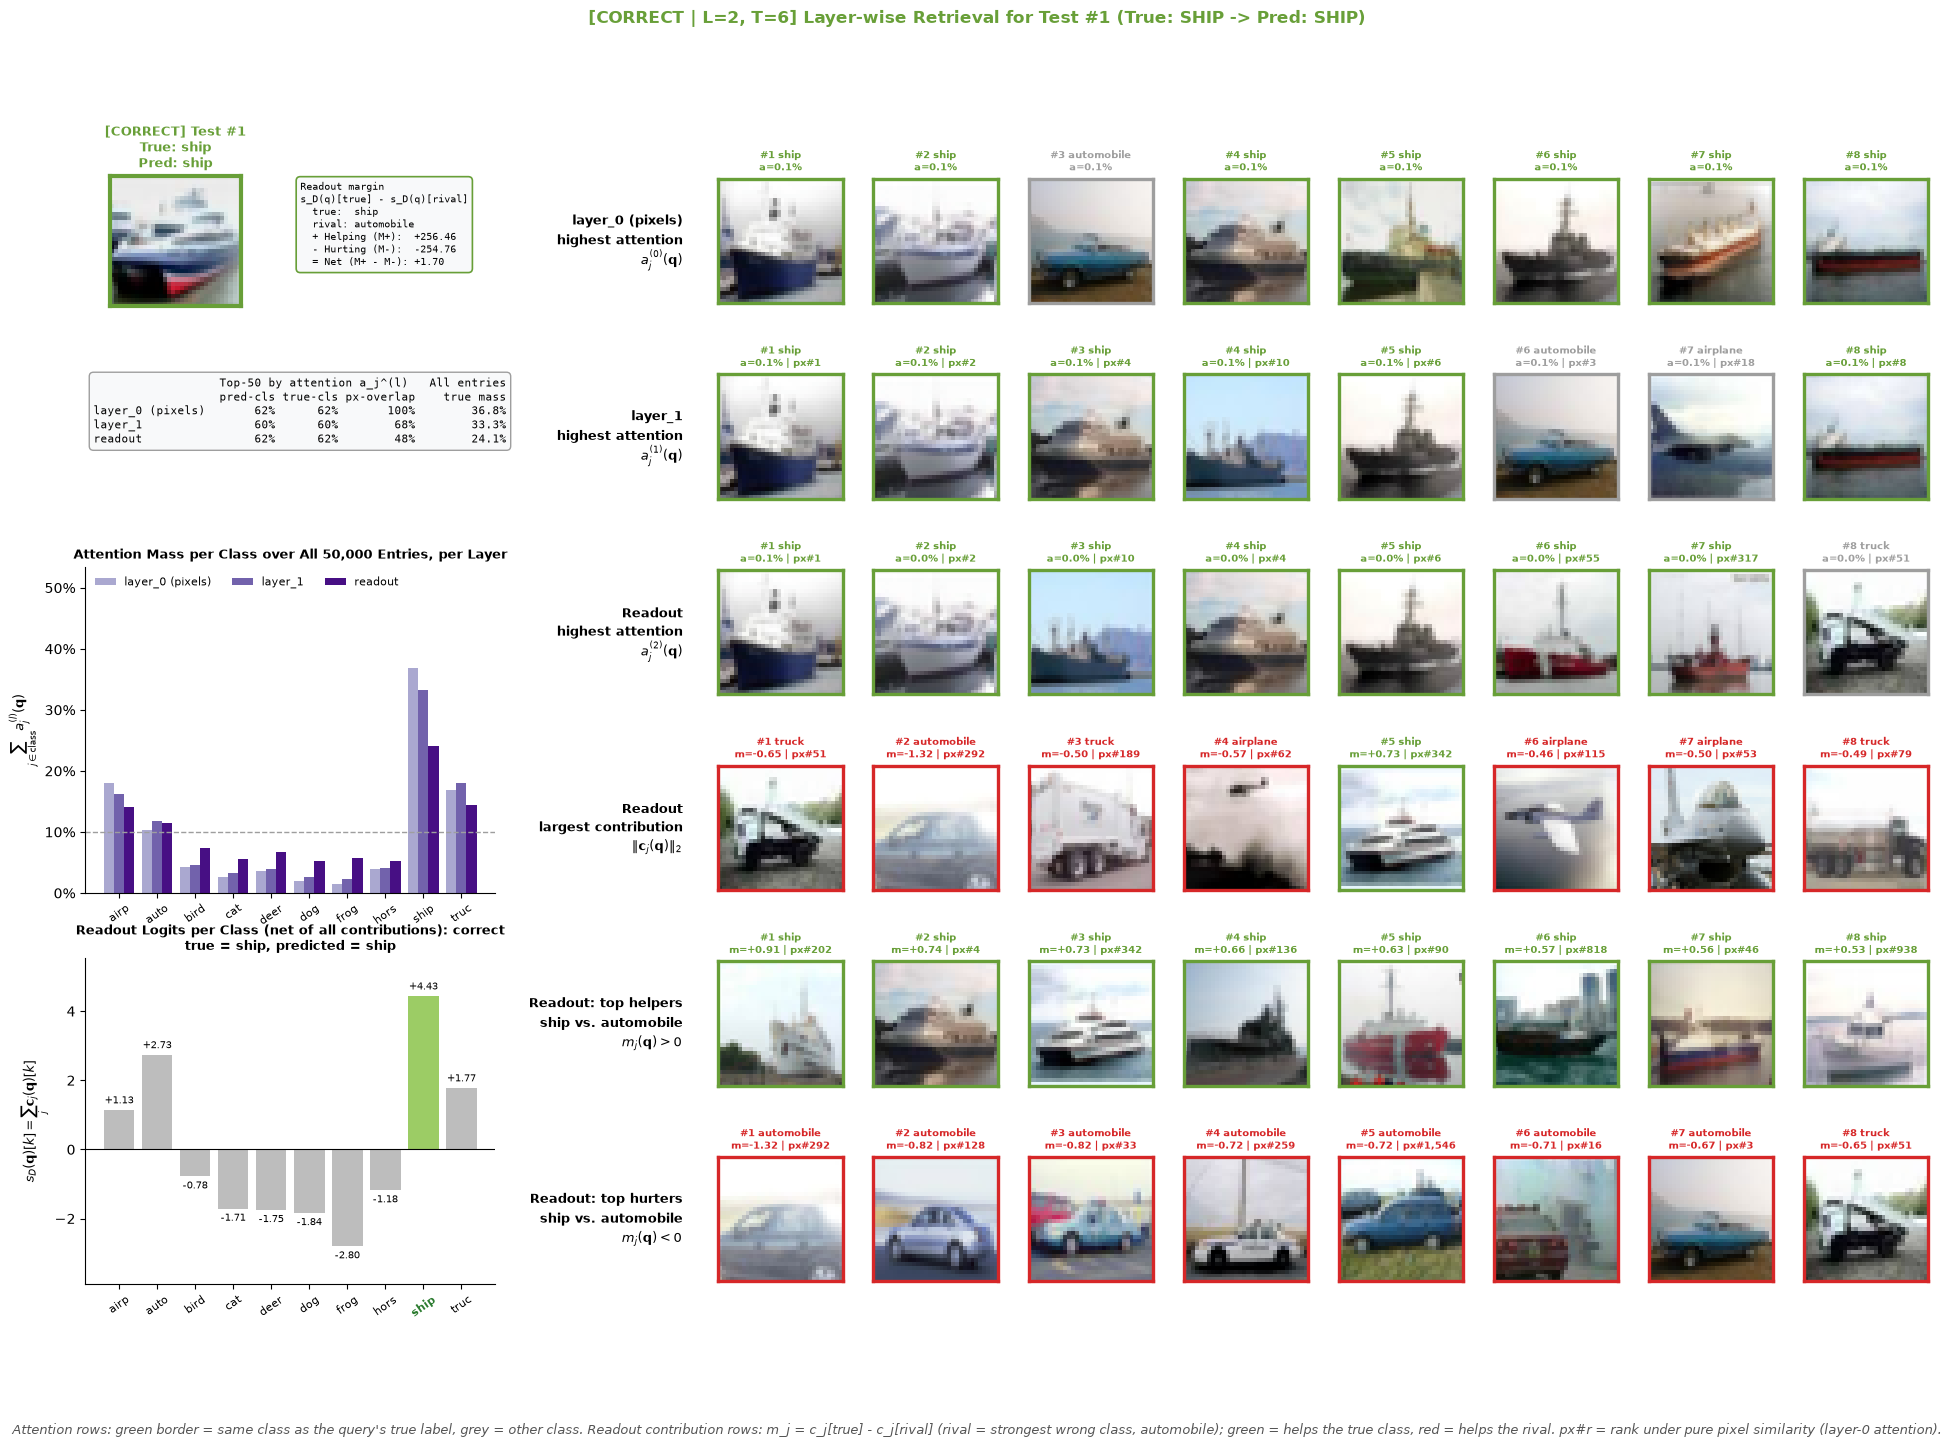

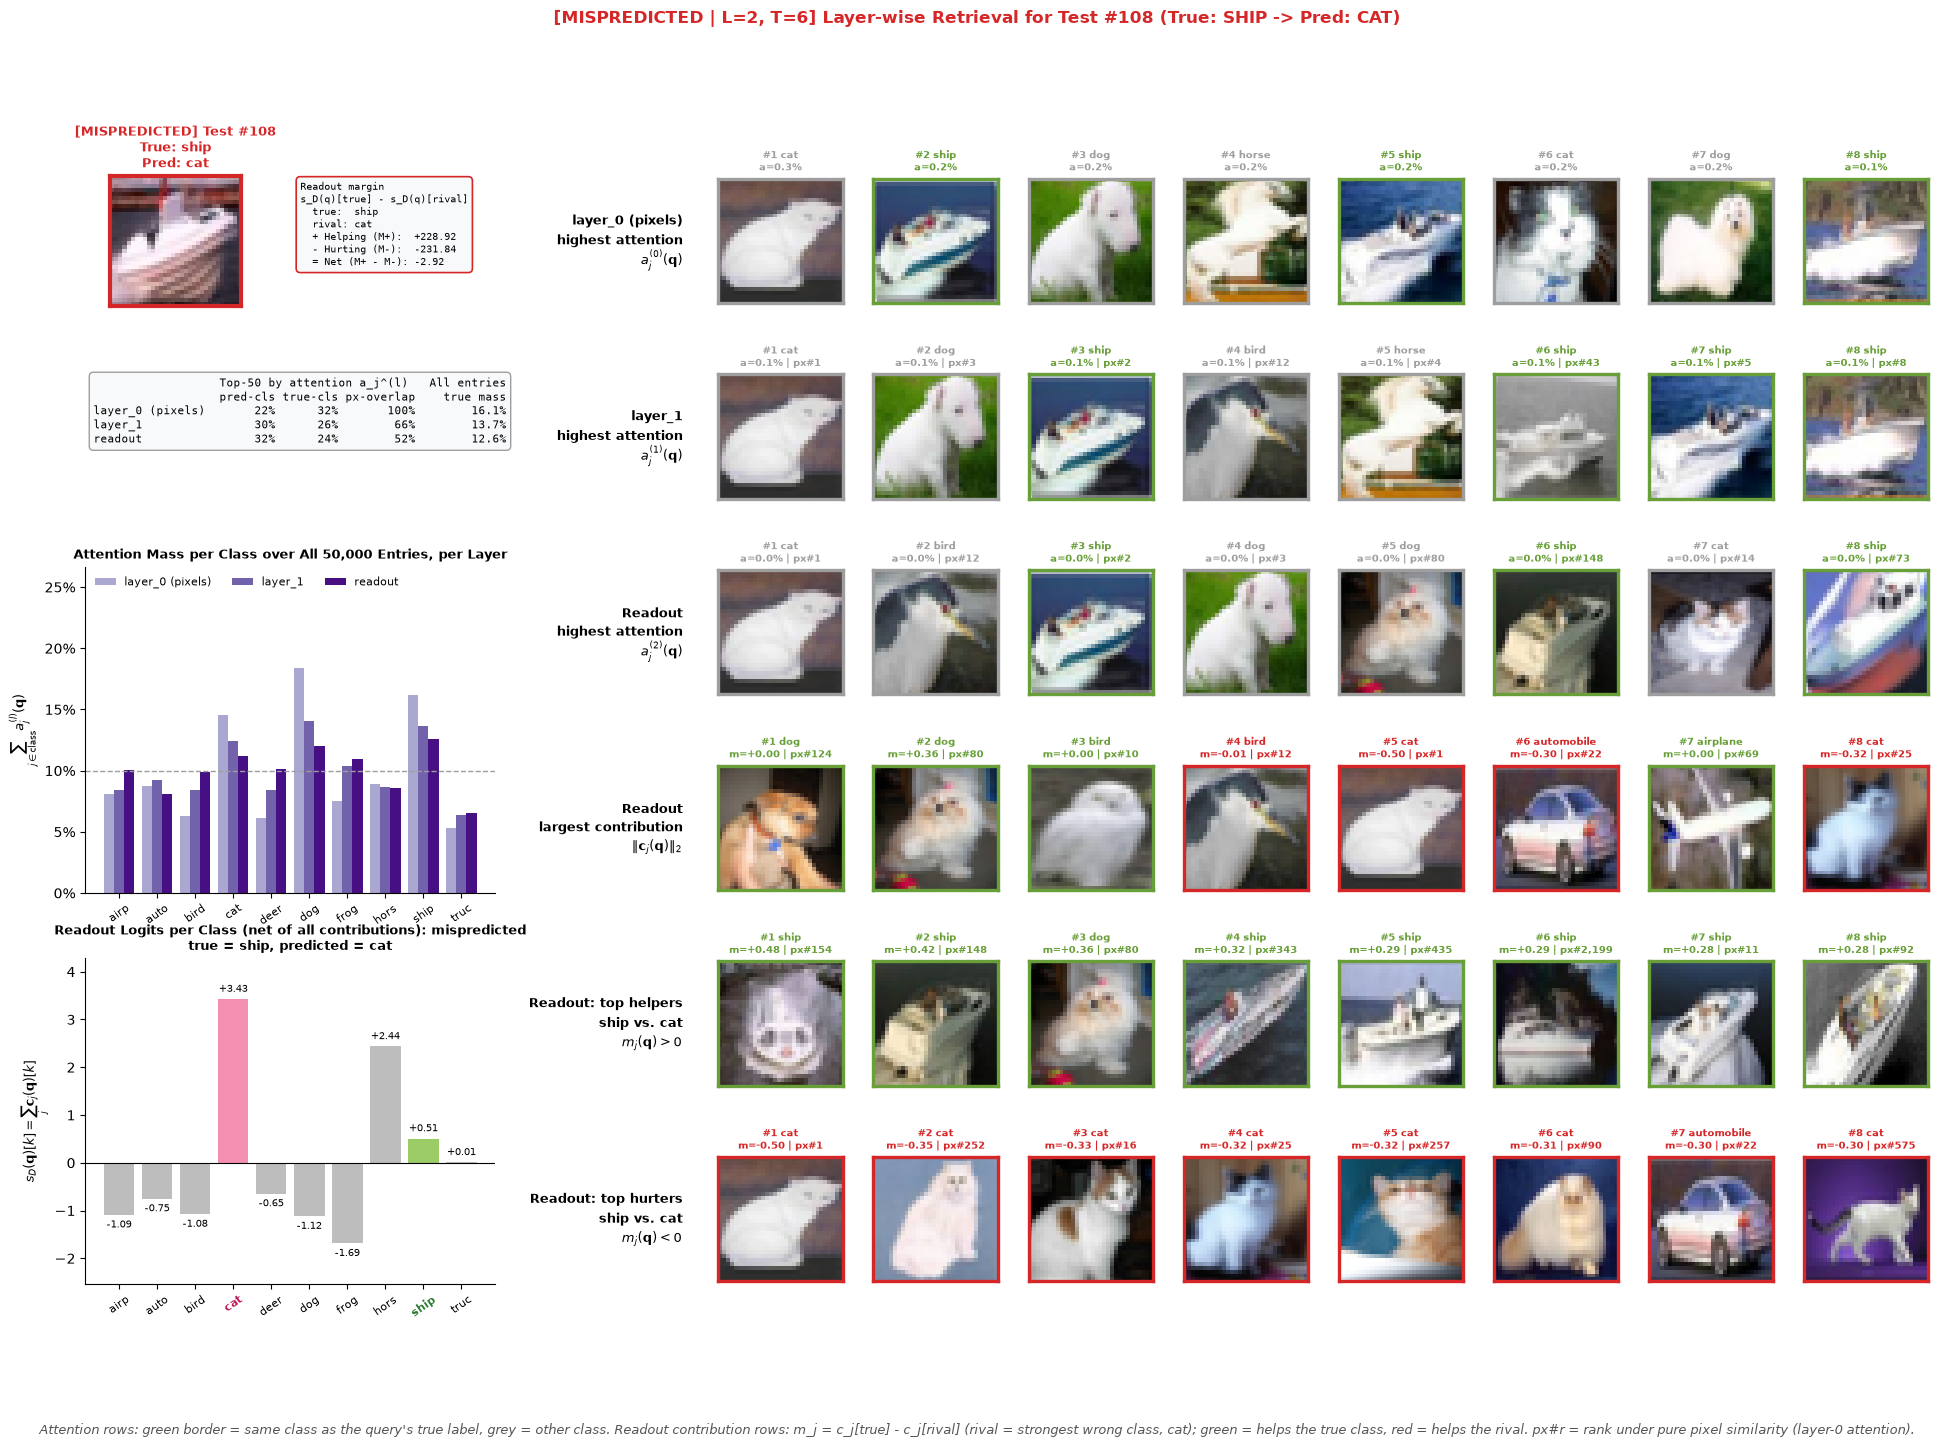

In [12]:
#@title 11.1 Train (or Reuse) the Best Multi-Layer Growing Weighted Softmax & Explore Layer-wise Retrieval

# --- Model (defaults = best-performing configuration; reuses gws_result from 5.1 if identical) ---
NUM_LAYERS = 2  # @param {type:"integer"}
TEMPERATURE = 6.0  # @param {type:"number"}
BETA = 3.0  # @param {type:"number"}
ETA = 0.003  # @param {type:"number"}
MOMENTUM = 0.0  # @param {type:"number"}
BATCH_SIZE = 16  # @param {type:"integer"}
EVAL_EVERY = 500  # @param {type:"integer"}
FORCE_RETRAIN_DEEP = False  # @param {type:"boolean"}
# --- Explorer display controls ---
PREDICTION_FILTER = "Both (1 Correct + 1 Mispredicted per class)"  # @param ["Both (1 Correct + 1 Mispredicted per class)", "Correctly Predicted Only", "Mispredicted Only"]
QUERY_CLASSES = "airplane, ship"  # @param {type:"string"}
EXAMPLES_PER_MODE = 1  # @param {type:"slider", min:1, max:3, step:1}
TEST_INDICES = ""  # @param {type:"string"}
TOP_K = 8  # @param {type:"slider", min:4, max:12, step:1}
# TEST_INDICES: optional comma-separated test indices (e.g. "12, 345"); overrides the class filter.


# --- 1. Train or reuse the model --------------------------------------------
if '_gws_deep_model_cache' not in globals():
  _gws_deep_model_cache = {}

_deep_cache_key = (int(NUM_LAYERS), round(float(TEMPERATURE), 4), round(float(BETA), 4), round(float(ETA), 6),
                   round(float(MOMENTUM), 4), int(BATCH_SIZE))

# Reuse gws_result from Section 5.1 if it matches the requested hyperparameters
if (not FORCE_RETRAIN_DEEP and _deep_cache_key not in _gws_deep_model_cache
    and globals().get('gws_result') is not None and 'model' in gws_result):
  _c5 = gws_result['cfg']
  if (_c5.num_layers, round(float(_c5.temperature), 4), round(float(_c5.beta), 4), round(float(_c5.eta), 6),
      round(float(_c5.model_momentum), 4), _c5.batch_size) == _deep_cache_key:
    _gws_deep_model_cache[_deep_cache_key] = (_c5, gws_result)

if FORCE_RETRAIN_DEEP or _deep_cache_key not in _gws_deep_model_cache:
  gws_deep_cfg = RCDLConfig(
      kernel_type='gws',
      hidden_dim=3072,
      num_layers=int(NUM_LAYERS),
      temperature=float(TEMPERATURE),
      beta=float(BETA),
      model_momentum=float(MOMENTUM),
      db_size=(50000 // int(BATCH_SIZE)) * int(BATCH_SIZE) + int(BATCH_SIZE),
      num_classes=10,
      batch_size=int(BATCH_SIZE),
      eta=float(ETA),
      learning_rate=3e-4,
      num_epochs=1,
      global_init_seed=1,
  )
  gws_deep_result = run_rcdl_experiment(gws_deep_cfg, eval_every=EVAL_EVERY, keep_model=True)
  _ = plot_rcdl_result(gws_deep_result)
  _gws_deep_model_cache[_deep_cache_key] = (gws_deep_cfg, gws_deep_result)
else:
  gws_deep_cfg, gws_deep_result = _gws_deep_model_cache[_deep_cache_key]
  print(f'Using cached Growing Weighted Softmax, L={gws_deep_cfg.num_layers} (T={gws_deep_cfg.temperature:g}, '
        f'η={gws_deep_cfg.eta:g}, β={gws_deep_cfg.beta:g} | Final Test Acc: {gws_deep_result["final_test_acc"]*100:.2f}%)')
gws_deep_model = gws_deep_result['model']


# --- 2. Layer-wise forward pass that exposes every layer's attention ---------
def gws_deep_layer_label(l_idx: int, cfg: RCDLConfig) -> str:
  if l_idx == cfg.num_layers:
    return 'readout'
  return 'layer_0 (pixels)' if l_idx == 0 else f'layer_{l_idx}'


def gws_deep_layer_data(model: CifarRCDLClassifier) -> list:
  """Collects keys, weighted values ṽ_j, weights w_j and validity masks of all layers (layer_0, ..., output_layer)."""
  out = []
  for layer in model.rcdl_layers().values():
    keys, values, weights = layer.keys.detach(), layer.values.detach(), layer.weights.detach()[:, 0]
    out.append({'keys': keys, 'values': values, 'weights': weights, 'v_norms': values.norm(dim=-1),
                'valid': (keys != 0).any(-1) | (weights != 0)})
  return out


def gws_deep_layer_attention(x: torch.Tensor, ld: Dict[str, torch.Tensor], temperature: float):
  """One Growing Weighted Softmax layer (same math as weighted_attention in 3.1).

  Returns z_j, pure attention a_j = softmax(z)_j, effective weights ã_j = e^{z_j} / Σ_m w_m e^{z_m},
  and the layer output s = Σ_j ã_j ṽ_j.
  """
  q = rms_norm(x)   # RMSNorm (no learned scale)
  z = q @ ld['keys'].T / (temperature * math.sqrt(q.shape[-1]))
  z = torch.where(ld['valid'][None, :], z, torch.full_like(z, -1e9))
  e = torch.where(ld['valid'][None, :], torch.exp(z - z.max(-1, keepdim=True).values), torch.zeros_like(z))
  a = e / e.sum(-1, keepdim=True)
  denom = (e * ld['weights'][None, :]).sum(-1, keepdim=True)
  sign = torch.where(denom < 0, -torch.ones_like(denom), torch.ones_like(denom))
  a_tilde = e / (denom.abs().clamp_min(1e-8) * sign)
  return z, a, a_tilde, a_tilde @ ld['values']


@torch.no_grad()
def gws_deep_run(test_idx_list, with_attn: bool = True, batch_size: int = 500):
  """Replays the forward pass on test images; returns the logits and every layer's attention a_j and ã_j (NumPy)."""
  act, temperature = ACTIVATIONS[gws_deep_cfg.nonlinearity], float(gws_deep_cfg.temperature)
  idx = torch.as_tensor(np.asarray(test_idx_list, dtype=np.int64), device=DEVICE)
  logits_all, attn_all, at_all = [], [[] for _ in gws_deep_layers], [[] for _ in gws_deep_layers]
  for i in range(0, len(idx), batch_size):
    x = test_x[idx[i:i + batch_size]]
    for l_idx, ld in enumerate(gws_deep_layers):
      _, a, a_tilde, y = gws_deep_layer_attention(x, ld, temperature)
      if with_attn:
        attn_all[l_idx].append(a.cpu().numpy())
        at_all[l_idx].append(a_tilde.cpu().numpy())
      if l_idx < len(gws_deep_layers) - 1:
        x = (x + act(y)) if gws_deep_cfg.use_residual else act(y)
    logits_all.append(y.cpu().numpy())
  logits = np.concatenate(logits_all)
  if not with_attn:
    return logits, None, None
  return logits, [np.concatenate(v) for v in attn_all], [np.concatenate(v) for v in at_all]


gws_deep_layers = gws_deep_layer_data(gws_deep_model)


# --- 3. Sanity checks: replay == model, and entry j <-> training image -------
_n_init = int(gws_deep_cfg.batch_size)   # |D_0| = B random initial entries
gws_deep_model.eval()
with torch.no_grad():
  _ref_logits = gws_deep_model(test_x[:500]).cpu().numpy()
_rep_logits = gws_deep_run(list(range(500)), with_attn=False)[0]
print(f'Replayed forward pass vs. model: max |Δ logits| = {float(np.max(np.abs(_ref_logits - _rep_logits))):.2e}')

deep_perm = gws_deep_result['perm']   # training image streamed at step i -> entry B + i in every layer
_n_db = int(gws_deep_layers[0]['keys'].shape[0])
_n_train_entries = min(_n_db - _n_init, len(deep_perm))
deep_entry_train_idx = np.full((_n_db,), -1, dtype=np.int64)  # -1 = random initial entry (D_0)
deep_entry_train_idx[_n_init:_n_init + _n_train_entries] = deep_perm[:_n_train_entries]
deep_entry_labels = np.where(deep_entry_train_idx >= 0, train_labels[np.maximum(deep_entry_train_idx, 0)], -1)

_chk = rms_norm(train_x[torch.as_tensor(deep_perm[:64], device=DEVICE)])
_k0 = gws_deep_layers[0]['keys'][_n_init:_n_init + 64]
print(f'Verified entry alignment (layer_0 entries {_n_init}.. <-> train_images[deep_perm]): '
      f'max |key - RMSNorm(img)| = {(_k0 - _chk).abs().max().item():.2e}')


# --- 4. Per-query layer-wise attribution -------------------------------------
def compute_gws_deep_attribution(test_idx: int, top_stats: int = 50) -> Dict[str, Any]:
  """Per-layer pure attention a_j^(l), contribution norms, and exact readout contributions c_j(q)."""
  logits, attns, a_tildes = gws_deep_run([test_idx])
  logits = logits[0]
  true_label = int(test_labels[test_idx])
  pred_label = int(np.argmax(logits))
  tr = slice(_n_init, _n_init + _n_train_entries)  # restrict to entries written by training images
  t_labels = deep_entry_labels[tr]

  layers = []
  for l_idx, ld in enumerate(gws_deep_layers):
    a = 100.0 * attns[l_idx][0][tr]                                               # % of attention mass
    mag = np.abs(a_tildes[l_idx][0][tr]) * ld['v_norms'].cpu().numpy()[tr]        # ||c_j^(l)(q)||_2
    layers.append({'attn': a, 'mag': mag, 'order': np.argsort(-a)})

  # Rank of every entry under pure pixel similarity (= layer-0 attention)
  px_rank = np.empty(_n_train_entries, dtype=np.int64)
  px_rank[layers[0]['order']] = np.arange(_n_train_entries)

  top0 = set(layers[0]['order'][:top_stats].tolist())
  for lay in layers:
    top = lay['order'][:top_stats]
    lay['purity_pred'] = 100.0 * float(np.mean(t_labels[top] == pred_label))
    lay['purity_true'] = 100.0 * float(np.mean(t_labels[top] == true_label))
    lay['pixel_overlap'] = 100.0 * len(top0.intersection(top.tolist())) / float(top_stats)
    # Attention mass per class over ALL entries written by training images (in % of the layer's total mass)
    lay['class_mass'] = np.bincount(t_labels, weights=lay['attn'], minlength=10)

  # Exact readout decomposition: s_D(q) = Σ_j c_j(q), c_j(q) = ã_j(q) ṽ_j
  values_out = gws_deep_layers[-1]['values'].cpu().numpy()[tr]
  contrib = a_tildes[-1][0][tr][:, None] * values_out                # (n_train, 10)
  # Margin view: rival r = strongest wrong class; m_j(q) = c_j(q)[y] - c_j(q)[r] sums to the
  # margin s_D(q)[y] - s_D(q)[r], which is > 0 iff the prediction is correct.
  rival_label = int(np.argmax(np.where(np.arange(logits.shape[0]) == true_label, -np.inf, logits)))
  margin_scores = contrib[:, true_label] - contrib[:, rival_label]

  return {
      'test_idx': test_idx,
      'true_label': true_label,
      'pred_label': pred_label,
      'logits': logits,
      'layers': layers,
      'px_rank': px_rank,
      'rival_label': rival_label,
      'margin_scores': margin_scores,
      'contrib': contrib,
      'm_plus': float(np.sum(margin_scores[margin_scores > 0])),
      'm_minus': float(np.sum(np.abs(margin_scores[margin_scores < 0]))),
      'train_labels_ordered': t_labels,
      'train_idx_ordered': deep_entry_train_idx[tr],
      'top_stats': top_stats,
  }


def _fmt_rank(r: int) -> str:
  return f'{r:,}' if r < 10000 else f'{r / 1000:.0f}k'


def plot_readout_logits(ax, contrib: np.ndarray, true_c: int, pred_c: int):
  """Net readout logits s_D(q)[k] = Σ_j c_j(q)[k] for all 10 classes (after all cancellations).

  The highest bar is the predicted class. Green = true class, pink = predicted class if wrong.
  """
  logits = np.sum(contrib, axis=0)   # (10,)
  x_idx = np.arange(logits.shape[0])
  cols = ['#9ccc65' if k == true_c else ('#f48fb1' if k == pred_c else '#bdbdbd') for k in x_idx]
  ax.bar(x_idx, logits, color=cols)
  ax.axhline(0.0, color='black', lw=0.8)
  span = max(1e-6, float(np.max(np.abs(logits))))
  for xi, v in zip(x_idx, logits):
    ax.text(xi, v + (0.03 if v >= 0 else -0.03) * span, f'{v:+.2f}', ha='center',
            va='bottom' if v >= 0 else 'top', fontsize=7.2)
  ax.set_ylim(min(0.0, float(logits.min())) - 0.25 * span, max(0.0, float(logits.max())) + 0.25 * span)
  ax.set_xticks(x_idx)
  ax.set_xticklabels([c[:4] for c in CIFAR10_CLASSES], rotation=35, fontsize=8)
  for k, tl in enumerate(ax.get_xticklabels()):
    if k in (true_c, pred_c):
      tl.set_color('#2e7d32' if k == true_c else '#c2185b')
      tl.set_fontweight('bold')
  ax.set_ylabel(r'$s_D(\mathbf{q})[k] = \sum_j \mathbf{c}_j(\mathbf{q})[k]$', fontsize=9)
  verdict = 'correct' if pred_c == true_c else 'mispredicted'
  ax.set_title(f'Readout Logits per Class (net of all contributions): {verdict}\n'
               f'true = {CIFAR10_CLASSES[true_c]}, predicted = {CIFAR10_CLASSES[pred_c]}',
               fontsize=9, weight='bold')
  for sp in ('top', 'right'):
    ax.spines[sp].set_visible(False)


def plot_gws_deep_attribution(attr: Dict[str, Any], cfg: RCDLConfig, top_k: int = 8):
  """Rows: top-K by attention in every layer, then the readout's contribution, margin-helper & margin-hurter rows."""
  test_idx, true_c, pred_c = attr['test_idx'], attr['true_label'], attr['pred_label']
  is_correct = (true_c == pred_c)
  layers = attr['layers']
  n_lay = len(layers)
  t_labels = attr['train_labels_ordered']
  t_idx = attr['train_idx_ordered']
  rival_c = attr['rival_label']
  signed = attr['margin_scores']   # m_j(q) = c_j(q)[true] - c_j(q)[rival] at the readout
  px_rank = attr['px_rank']
  readout = layers[-1]
  pred_name = CIFAR10_CLASSES[pred_c]
  true_name, rival_name = CIFAR10_CLASSES[true_c], CIFAR10_CLASSES[rival_c]
  vs_str = f'{true_name} vs. {rival_name}'
  match_col = '#689f38' if is_correct else '#d62728'
  verdict_str = 'CORRECT' if is_correct else 'MISPREDICTED'
  n_stat = attr['top_stats']

  # (row label, entry indices, row type, layer index)
  row_configs = []
  for l_idx in range(n_lay):
    lbl = gws_deep_layer_label(l_idx, cfg)
    if l_idx == cfg.num_layers:
      lbl = 'Readout'
    row_configs.append((
        f'{lbl}\nhighest attention\n' + rf'$a^{{({l_idx})}}_j(\mathbf{{q}})$',
        layers[l_idx]['order'][:top_k], 'attn', l_idx))
  row_configs += [
      ('Readout\nlargest contribution\n' + r'$\Vert\mathbf{c}_j(\mathbf{q})\Vert_2$',
       np.argsort(-readout['mag'])[:top_k], 'mag', n_lay - 1),
      (f'Readout: top helpers\n{vs_str}\n' + r'$m_j(\mathbf{q}) > 0$',
       np.argsort(-signed)[:top_k], 'pos', n_lay - 1),
      (f'Readout: top hurters\n{vs_str}\n' + r'$m_j(\mathbf{q}) < 0$',
       np.argsort(signed)[:top_k], 'neg', n_lay - 1),
  ]
  n_rows = len(row_configs)

  n_left = 3
  fig = plt.figure(figsize=(2.05 * (top_k + 3.6), 2.3 * n_rows + 0.6))
  gs = fig.add_gridspec(n_rows, top_k + n_left, width_ratios=[1.45, 1.6, 1.3] + [1.0] * top_k,
                        hspace=0.5, wspace=0.22)

  # --- Query image ---
  ax_q = fig.add_subplot(gs[0, 0])
  ax_q.imshow(unnormalize_cifar(test_images[test_idx])[0])
  ax_q.set_title(f'[{verdict_str}] Test #{test_idx}\nTrue: {CIFAR10_CLASSES[true_c]}\n'
                 f'Pred: {pred_name}', fontsize=9.5, weight='bold', color=match_col)
  for spine in ax_q.spines.values():
    spine.set_edgecolor(match_col)
    spine.set_linewidth(3.0)
  ax_q.set_xticks([])
  ax_q.set_yticks([])

  # --- Readout margin decomposition ---
  ax_stat = fig.add_subplot(gs[0, 1])
  ax_stat.axis('off')
  stat_txt = (f"Readout margin\n"
              f"s_D(q)[true] - s_D(q)[rival]\n"
              f"  true:  {true_name}\n"
              f"  rival: {rival_name}\n"
              f"  + Helping (M+):  +{attr['m_plus']:.2f}\n"
              f"  - Hurting (M-):  -{attr['m_minus']:.2f}\n"
              f"  = Net (M+ - M-): {attr['m_plus'] - attr['m_minus']:+.2f}")
  ax_stat.text(0.02, 0.96, stat_txt, va='top', ha='left', fontsize=7.4, family='monospace',
               bbox=dict(boxstyle='round,pad=0.4', facecolor='#f8f9fa', edgecolor=match_col, lw=1.2))

  # --- Depth table: purity & pixel overlap of the top-50 by attention per layer ---
  ax_tab = fig.add_subplot(gs[1, 0:2])
  ax_tab.axis('off')
  tab_txt = (f"{'':<17}{'Top-' + str(n_stat) + ' by attention a_j^(l)':^29}{'All entries':>13}\n"
             f"{'':<17}{'pred-cls':>9}{'true-cls':>9}{'px-overlap':>11}{'true mass':>13}\n")
  for l_idx, lay in enumerate(layers):
    tab_txt += (f"{gws_deep_layer_label(l_idx, cfg):<17}{lay['purity_pred']:>8.0f}%"
                f"{lay['purity_true']:>8.0f}%{lay['pixel_overlap']:>10.0f}%"
                f"{lay['class_mass'][true_c]:>12.1f}%\n")
  ax_tab.text(0.02, 0.96, tab_txt.rstrip('\n'), va='top', ha='left', fontsize=7.6, family='monospace',
              bbox=dict(boxstyle='round,pad=0.4', facecolor='#f8f9fa', edgecolor='#9e9e9e', lw=1.0))

  # --- Attention mass per class over ALL entries, per layer ---
  h_rows = max(1, (n_rows - 2) // 2)
  ax_hist = fig.add_subplot(gs[2:2 + h_rows, 0:2])
  x_idx = np.arange(10)
  bar_w = 0.8 / n_lay
  lay_cols = plt.cm.Purples(np.linspace(0.45, 0.95, n_lay))
  max_mass = 10.0
  for l_idx, lay in enumerate(layers):
    max_mass = max(max_mass, float(lay['class_mass'].max()))
    ax_hist.bar(x_idx - 0.4 + bar_w * (l_idx + 0.5), lay['class_mass'], width=bar_w,
                color=lay_cols[l_idx], label=gws_deep_layer_label(l_idx, cfg))
  ax_hist.axhline(10.0, ls='--', lw=1.0, color='#9e9e9e')
  ax_hist.set_xticks(x_idx)
  ax_hist.set_xticklabels([c[:4] for c in CIFAR10_CLASSES], rotation=35, fontsize=8)
  ax_hist.set_ylabel(r'$\sum_{j \in \mathrm{class}} a^{(l)}_j(\mathbf{q})$', fontsize=9)
  ax_hist.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100.0, decimals=0))
  ax_hist.set_title(f'Attention Mass per Class over All {len(t_labels):,} Entries, per Layer',
                    fontsize=9, weight='bold')
  ax_hist.set_ylim(0, 1.45 * max_mass)
  ax_hist.legend(fontsize=7.6, loc='upper left', frameon=False, ncol=min(3, n_lay))
  for sp in ('top', 'right'):
    ax_hist.spines[sp].set_visible(False)

  # --- Readout: net logits per class ---
  if 2 + h_rows < n_rows:
    ax_cancel = fig.add_subplot(gs[2 + h_rows:, 0:2])
    plot_readout_logits(ax_cancel, attr['contrib'], true_c, pred_c)

  # --- Thumbnail rows ---
  for row_i, (row_label, indices, r_type, l_idx) in enumerate(row_configs):
    ax_lbl = fig.add_subplot(gs[row_i, n_left - 1])
    ax_lbl.axis('off')
    ax_lbl.text(0.97, 0.5, row_label, ha='right', va='center', fontsize=9.5,
                weight='bold', linespacing=1.5, transform=ax_lbl.transAxes)
    for rank, entry_i in enumerate(indices):
      ax = fig.add_subplot(gs[row_i, rank + n_left])
      ax.imshow(unnormalize_cifar(train_images[int(t_idx[entry_i])])[0])
      cls_i = int(t_labels[entry_i])
      a_val = float(layers[l_idx]['attn'][entry_i])
      px_str = f'px#{_fmt_rank(int(px_rank[entry_i]) + 1)}'
      if r_type == 'attn':
        border_col = '#689f38' if cls_i == true_c else '#9e9e9e'
        sub_txt = f'a={a_val:.1f}%' if l_idx == 0 else f'a={a_val:.1f}% | {px_str}'
      else:
        s_val = float(signed[entry_i])
        border_col = '#689f38' if s_val >= 0 else '#d62728'
        sub_txt = f'm={s_val:+.2f} | {px_str}'
      for spine in ax.spines.values():
        spine.set_edgecolor(border_col)
        spine.set_linewidth(2.4)
      ax.set_xticks([])
      ax.set_yticks([])
      ax.set_title(f'#{rank + 1} {CIFAR10_CLASSES[cls_i]}\n{sub_txt}',
                   fontsize=7.3, color=border_col, weight='bold')

  fig.suptitle(
      f'[{verdict_str} | L={cfg.num_layers}, T={cfg.temperature:g}] Layer-wise Retrieval for '
      f'Test #{test_idx} (True: {CIFAR10_CLASSES[true_c].upper()} -> Pred: {pred_name.upper()})',
      fontsize=12, weight='bold', color=match_col, y=0.995)
  fig.text(0.5, 0.004,
           'Attention rows: green border = same class as the query\'s true label, grey = other class. '
           f'Readout contribution rows: m_j = c_j[true] - c_j[rival] (rival = strongest wrong class, {rival_name}); '
           'green = helps the true class, red = helps the rival. '
           'px#r = rank under pure pixel similarity (layer-0 attention).',
           ha='center', va='bottom', fontsize=9, style='italic', color='#555555')
  plt.tight_layout(rect=[0.0, 0.02, 1.0, 0.985])
  plt.show()
  return fig


# --- 5. Select queries & plot -----------------------------------------------
_explicit_idx = [int(s) for s in TEST_INDICES.replace(';', ',').split(',') if s.strip().isdigit()]
_explicit_idx = [i for i in _explicit_idx if 0 <= i < test_images.shape[0]]

if _explicit_idx:
  for tid in _explicit_idx:
    _ = plot_gws_deep_attribution(compute_gws_deep_attribution(tid), gws_deep_cfg, top_k=int(TOP_K))
else:
  parsed_classes = [c.strip().lower() for c in QUERY_CLASSES.split(',')
                    if c.strip().lower() in CIFAR10_CLASSES] or ['airplane']
  want_correct = PREDICTION_FILTER in ("Both (1 Correct + 1 Mispredicted per class)", "Correctly Predicted Only")
  want_mispred = PREDICTION_FILTER in ("Both (1 Correct + 1 Mispredicted per class)", "Mispredicted Only")
  for cls_name in parsed_classes:
    target_cid = CIFAR10_CLASSES.index(cls_name)
    cand = np.where(test_labels == target_cid)[0][:250]
    cand_pred = np.argmax(gws_deep_run(list(cand), with_attn=False)[0], axis=-1)
    chosen = []
    if want_correct:
      chosen += list(cand[cand_pred == target_cid][:EXAMPLES_PER_MODE])
    if want_mispred:
      chosen += list(cand[cand_pred != target_cid][:EXAMPLES_PER_MODE])
    for tid in chosen:
      _ = plot_gws_deep_attribution(compute_gws_deep_attribution(int(tid)), gws_deep_cfg, top_k=int(TOP_K))

Depth statistics (L=2, top-50):   0%|          | 0/20 [00:00<?, ?it/s]


Depth statistics over the test set (0.5s, replayed test acc. 59.18%):
Layer              | Purity (a_j) | Purity (||c_j||) | Px-overlap (a_j) | Px-overlap (||c_j||) | Mass on D_0
-------------------------------------------------------------------------------------------------------------
layer_0 (pixels)   |        28.1% |            19.3% |           100.0% |                42.4% |        0.0%
layer_1            |        32.7% |            20.2% |            54.9% |                32.8% |        0.0%
readout            |        36.0% |            19.6% |            32.5% |                20.2% |        0.0%


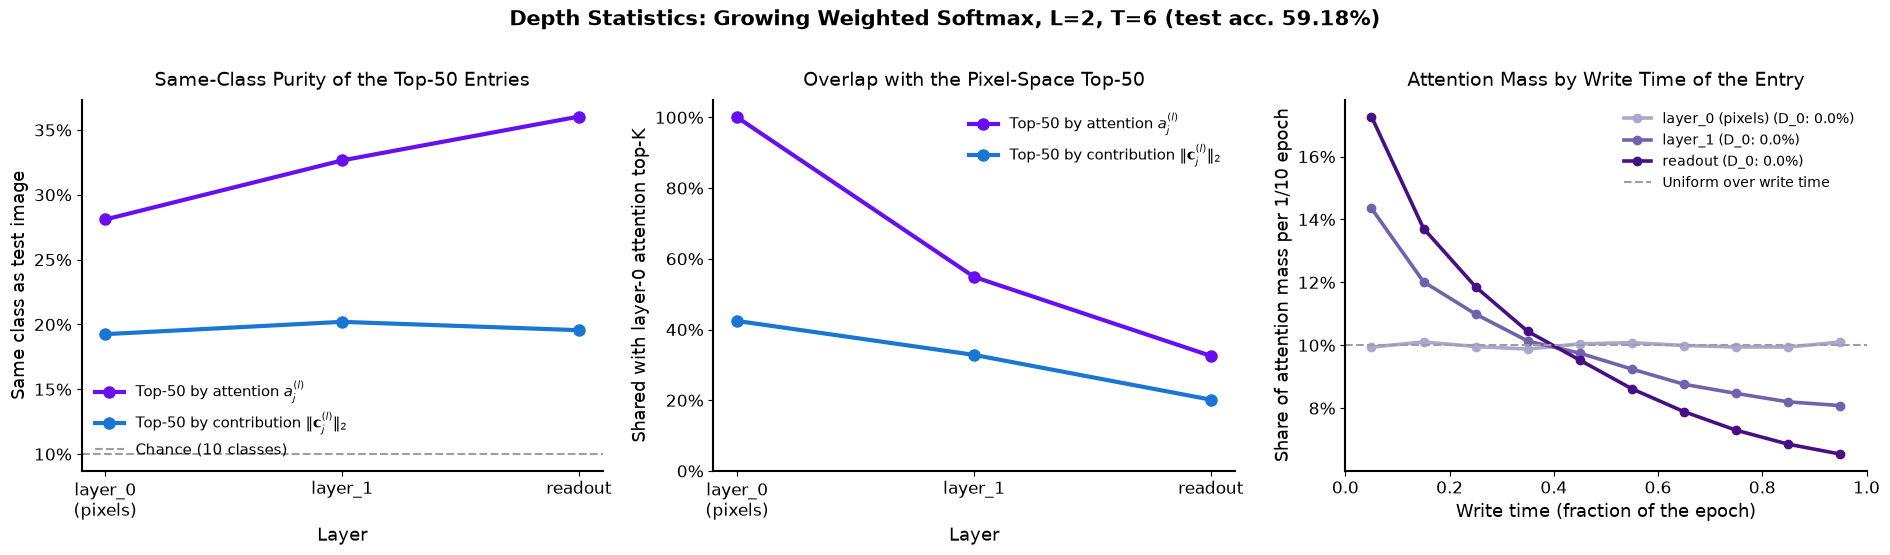

In [13]:
#@title 11.2 Depth Statistics: Does Retrieval Become More Semantic with Depth?

# Over all 10,000 test images and for every layer l of the model from 11.1, computes:
#   1. Same-class purity: fraction of the top-K entries (by attention a_j^(l) or by contribution
#      ||c_j^(l)||_2 = ã_j^(l) ||ṽ_j^(l)||_2) written by a training image of the test image's class.
#   2. Pixel overlap: fraction of the top-K entries that are also in the pixel-space top-K
#      (= top-K by layer-0 attention, whose query is the RMS-normalized image).
#   3. Attention mass by write time: share of the attention mass a_j^(l) on entries written in each
#      part of the epoch (keys of early entries were written with a much smaller database).
# The B random initial entries (D_0) are excluded from all rankings; their attention mass is reported separately.

STATS_TOP_K = 50  # @param {type:"integer"}
NUM_AGE_BINS = 10  # @param {type:"integer"}
FORCE_RECOMPUTE_STATS = False  # @param {type:"boolean"}

if 'gws_deep_result' not in globals():
  raise RuntimeError('Run 11.1 first: it trains (or reuses) the multi-layer Growing Weighted Softmax.')


@torch.no_grad()
def run_gws_depth_statistics(
    model: CifarRCDLClassifier,
    cfg: RCDLConfig,
    entry_labels: np.ndarray,
    top_k: int = 50,
    n_age_bins: int = 10,
    eval_batch_size: int = 500,
) -> Dict[str, Any]:
  """Single pass over the test set computing per-layer purity, pixel overlap & age profiles."""
  layers = gws_deep_layer_data(model)
  n_lay, temperature, act = len(layers), float(cfg.temperature), ACTIVATIONS[cfg.nonlinearity]

  labels_j = torch.as_tensor(entry_labels, device=DEVICE)      # (N,), -1 for D_0 entries
  is_train = labels_j >= 0
  n_init = int(np.argmax(entry_labels >= 0))                    # entries before the first training image = D_0
  n_train = int(np.sum(entry_labels >= 0))
  pos = torch.arange(len(labels_j), device=DEVICE) - n_init
  age_bin = torch.where(is_train, (pos * n_age_bins // n_train).clamp(0, n_age_bins - 1), torch.full_like(pos, n_age_bins))
  bin_onehot = F.one_hot(age_bin, n_age_bins + 1).float()       # last column = D_0
  neg_inf = torch.tensor(-float('inf'), device=DEVICE)

  n_eval = (len(test_x) // eval_batch_size) * eval_batch_size
  tot = {k: np.zeros(n_lay) for k in ('pur_att', 'pur_mag', 'ov_att', 'ov_mag')}
  tot_age = np.zeros((n_lay, n_age_bins + 1))
  tot_correct = 0.0

  t0 = time.time()
  for b_i in tqdm(range(0, n_eval, eval_batch_size), desc=f'Depth statistics (L={cfg.num_layers}, top-{top_k})'):
    x, by = test_x[b_i:b_i + eval_batch_size], test_y[b_i:b_i + eval_batch_size]
    top0 = None
    for l_idx, ld in enumerate(layers):
      z, a, a_tilde, y = gws_deep_layer_attention(x, ld, temperature)
      rankable = (is_train & ld['valid'])[None, :]
      idx_att = torch.where(rankable, z, neg_inf).topk(top_k, dim=-1).indices
      idx_mag = torch.where(rankable, z + torch.log(ld['v_norms'].clamp_min(1e-12))[None, :], neg_inf).topk(top_k, dim=-1).indices
      if top0 is None:
        top0 = idx_att
      tot['pur_att'][l_idx] += (labels_j[idx_att] == by[:, None]).float().mean(-1).sum().item()
      tot['pur_mag'][l_idx] += (labels_j[idx_mag] == by[:, None]).float().mean(-1).sum().item()
      tot['ov_att'][l_idx] += (idx_att[:, :, None] == top0[:, None, :]).any(-1).float().mean(-1).sum().item()
      tot['ov_mag'][l_idx] += (idx_mag[:, :, None] == top0[:, None, :]).any(-1).float().mean(-1).sum().item()
      tot_age[l_idx] += (a @ bin_onehot).sum(0).cpu().numpy()    # (n_age_bins + 1,)
      if l_idx < n_lay - 1:
        x = (x + act(y)) if cfg.use_residual else act(y)
    tot_correct += (y.argmax(-1) == by).sum().item()

  return {
      'cfg': cfg,
      'top_k': top_k,
      'n_age_bins': n_age_bins,
      'layer_labels': [gws_deep_layer_label(i, cfg) for i in range(n_lay)],
      'purity': {'attention': 100.0 * tot['pur_att'] / n_eval,
                 'contribution': 100.0 * tot['pur_mag'] / n_eval},
      'pixel_overlap': {'attention': 100.0 * tot['ov_att'] / n_eval,
                        'contribution': 100.0 * tot['ov_mag'] / n_eval},
      'age_mass': 100.0 * tot_age[:, :n_age_bins] / n_eval,   # (n_layers, n_age_bins), in %
      'd0_mass': 100.0 * tot_age[:, n_age_bins] / n_eval,     # (n_layers,), in %
      'test_acc': 100.0 * tot_correct / n_eval,
      'elapsed': time.time() - t0,
  }


def plot_gws_depth_statistics(res: Dict[str, Any]):
  """3 panels: same-class purity, pixel overlap, and attention mass by write time, per layer."""
  labels = [lbl.replace(' (pixels)', '\n(pixels)') for lbl in res['layer_labels']]
  n_lay = len(labels)
  x_l = np.arange(n_lay)
  k = res['top_k']
  specs = [
      ('attention', '#6610f2', rf'Top-{k} by attention $a^{{(l)}}_j$'),
      ('contribution', '#1976D2', rf'Top-{k} by contribution $\Vert\mathbf{{c}}^{{(l)}}_j\Vert_2$'),
  ]

  fig, (ax_pur, ax_ov, ax_age) = plt.subplots(1, 3, figsize=(19.0, 5.4))

  for r_key, col, lbl in specs:
    ax_pur.plot(x_l, res['purity'][r_key], marker='o', ms=8, lw=3.0, color=col, label=lbl)
    ax_ov.plot(x_l, res['pixel_overlap'][r_key], marker='o', ms=8, lw=3.0, color=col, label=lbl)
  ax_pur.axhline(10.0, ls='--', lw=1.5, color='#9E9E9E', label='Chance (10 classes)')
  ax_pur.set_title(f'Same-Class Purity of the Top-{k} Entries', fontsize=14, pad=10)
  ax_pur.set_ylabel('Same class as test image', fontsize=13)
  ax_ov.set_title(f'Overlap with the Pixel-Space Top-{k}', fontsize=14, pad=10)
  ax_ov.set_ylabel('Shared with layer-0 attention top-K', fontsize=13)
  ax_ov.set_ylim(0, 105)
  for ax in (ax_pur, ax_ov):
    ax.set_xticks(x_l)
    ax.set_xticklabels(labels, fontsize=12)
    ax.set_xlabel('Layer', fontsize=13)
    ax.legend(fontsize=10.5, frameon=False, loc='best')

  n_bins = res['n_age_bins']
  centers = (np.arange(n_bins) + 0.5) / n_bins
  lay_cols = plt.cm.Purples(np.linspace(0.45, 0.95, n_lay))
  for l_idx in range(n_lay):
    ax_age.plot(centers, res['age_mass'][l_idx], marker='o', ms=6, lw=2.6, color=lay_cols[l_idx],
                label=f"{res['layer_labels'][l_idx]} (D_0: {res['d0_mass'][l_idx]:.1f}%)")
  ax_age.axhline(100.0 / n_bins, ls='--', lw=1.5, color='#9E9E9E', label='Uniform over write time')
  ax_age.set_title('Attention Mass by Write Time of the Entry', fontsize=14, pad=10)
  ax_age.set_xlabel('Write time (fraction of the epoch)', fontsize=13)
  ax_age.set_ylabel(f'Share of attention mass per 1/{n_bins} epoch', fontsize=13)
  ax_age.set_xlim(0, 1)
  ax_age.legend(fontsize=10, frameon=False, loc='best')

  for ax in (ax_pur, ax_ov, ax_age):
    style_paper_ax(ax, fontsize_ticks=12)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100.0, decimals=0))

  fig.suptitle(f"Depth Statistics: Growing Weighted Softmax, L={res['cfg'].num_layers}, "
               f"T={res['cfg'].temperature:g} (test acc. {res['test_acc']:.2f}%)",
               fontsize=15, weight='bold', y=1.02)
  plt.tight_layout()
  plt.show()
  return fig


if (
    FORCE_RECOMPUTE_STATS
    or 'gws_depth_stats' not in globals()
    or gws_depth_stats.get('cfg') != gws_deep_cfg
    or gws_depth_stats.get('top_k') != int(STATS_TOP_K)
    or gws_depth_stats.get('n_age_bins') != int(NUM_AGE_BINS)
):
  gws_depth_stats = run_gws_depth_statistics(
      gws_deep_model, gws_deep_cfg, deep_entry_labels,
      top_k=int(STATS_TOP_K), n_age_bins=int(NUM_AGE_BINS))

print(f"\nDepth statistics over the test set ({gws_depth_stats['elapsed']:.1f}s, "
      f"replayed test acc. {gws_depth_stats['test_acc']:.2f}%):")
print(f"{'Layer':<18} | {'Purity (a_j)':>12} | {'Purity (||c_j||)':>16} | "
      f"{'Px-overlap (a_j)':>16} | {'Px-overlap (||c_j||)':>20} | {'Mass on D_0':>11}")
print('-' * 109)
for _l, _lbl in enumerate(gws_depth_stats['layer_labels']):
  print(f"{_lbl:<18} | {gws_depth_stats['purity']['attention'][_l]:>11.1f}% | "
        f"{gws_depth_stats['purity']['contribution'][_l]:>15.1f}% | "
        f"{gws_depth_stats['pixel_overlap']['attention'][_l]:>15.1f}% | "
        f"{gws_depth_stats['pixel_overlap']['contribution'][_l]:>19.1f}% | "
        f"{gws_depth_stats['d0_mass'][_l]:>10.1f}%")
_ = plot_gws_depth_statistics(gws_depth_stats)

1D+2D Top-K Sweep (2L + readout, T=6, η=0.003, β=3):   0%|          | 0/20 [00:00<?, ?it/s]


Completed 1D + 2D Top-K Sparsity Sweep in 17.8s (Full N=50,016 Acc: 59.18%)
   Top-K | % of database | Magnitude ||c_j||₂ |       Pure sim z_j
---------------------------------------------------------------
       1 |       0.00% |             19.66% |             33.64%
       3 |       0.01% |             15.96% |             26.66%
       5 |       0.01% |             15.72% |             24.92%
      10 |       0.02% |             14.62% |             24.60%
      25 |       0.05% |             13.85% |             25.58%
      50 |       0.10% |             12.95% |             26.53%
     100 |       0.20% |             12.43% |             26.90%
     250 |       0.50% |             12.43% |             29.34%
     500 |       1.00% |             12.53% |             33.12%
   1,000 |       2.00% |             12.31% |             37.53%
   2,500 |       5.00% |             11.38% |             44.97%
   5,000 |      10.00% |             11.59% |             48.27%
  10,000 |  

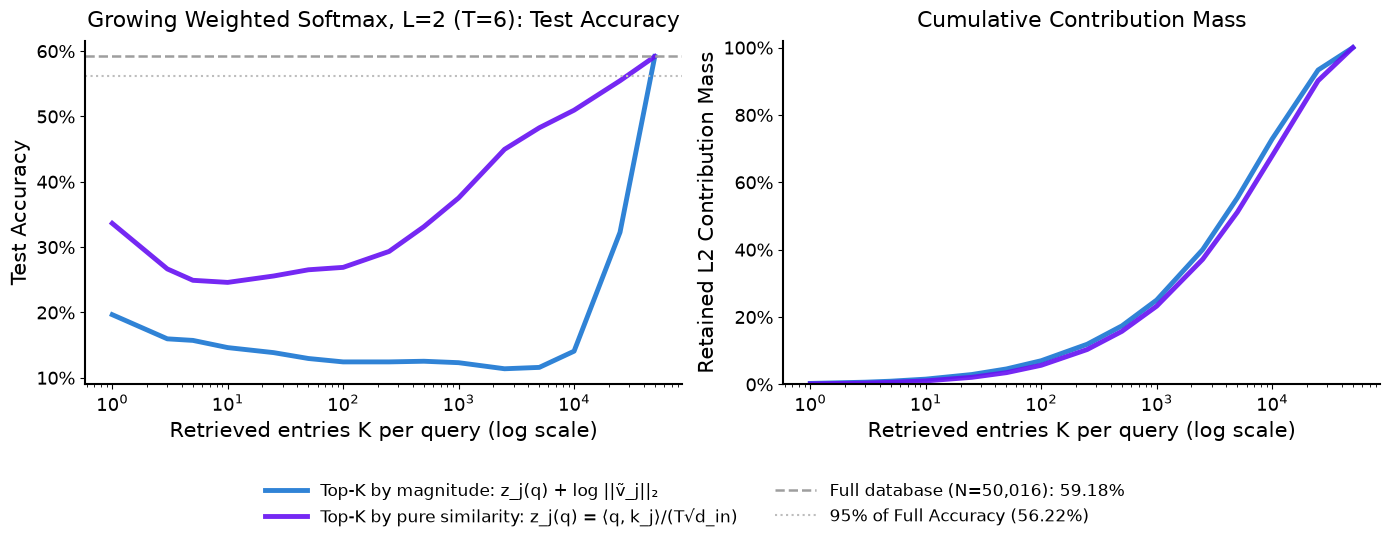

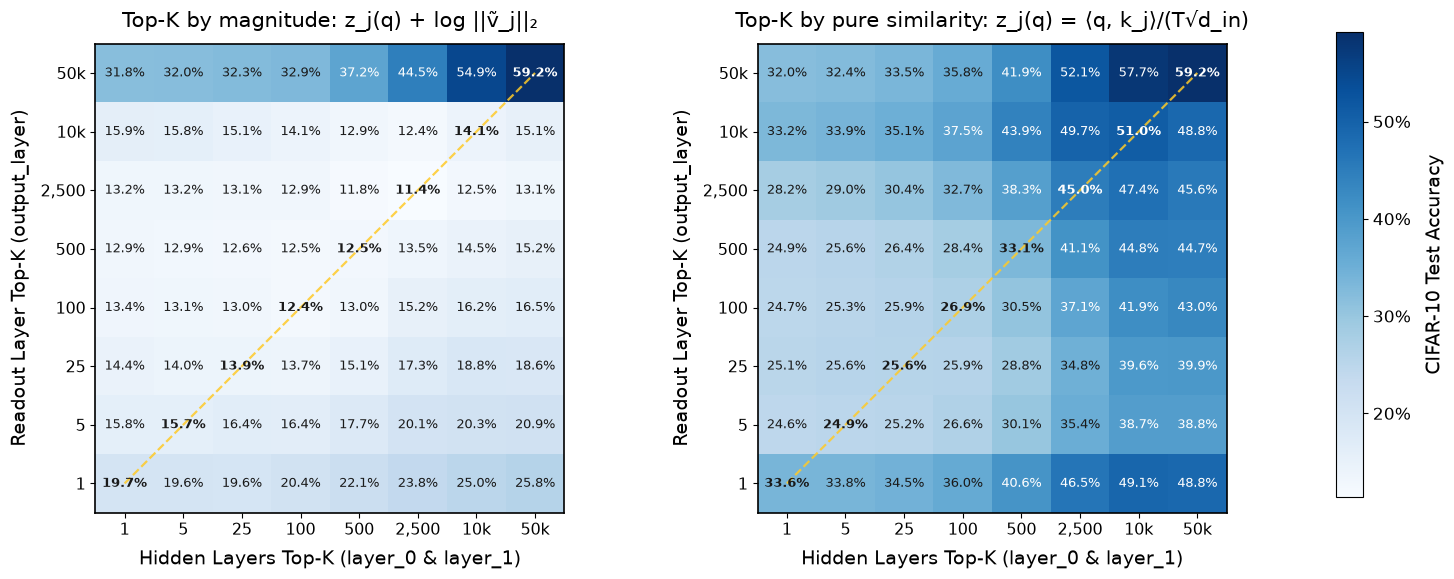

In [14]:
#@title 11.3 Top-K Sparsity Sweep & 2D Layer-wise Heatmap on the Multi-Layer Growing Weighted Softmax (from 11.1)

# Evaluates test-time Top-K sparsity on the multi-layer Growing Weighted Softmax from 11.1
# (default: L=2, T=6.0, η=0.003, β=3.0, momentum=0.0 -> ~59.3% test accuracy).
# Computes BOTH:
#   1. The 1D equal-sparsity curve (K_hidden = K_readout = K)
#   2. The full 2D accuracy heatmap (X-axis = Hidden Layers Top-K, Y-axis = Readout Layer Top-K)
# in a single pass over the test set.

FORCE_RERUN_SWEEP = False  # @param {type:"boolean"}

K_VALUES = [1, 3, 5, 10, 25, 50, 100, 250, 500, 1000, 2500, 5000, 10000, 25000, 50016]
HEATMAP_K_VALUES = [1, 5, 25, 100, 500, 2500, 10000, 50016]

if 'gws_deep_result' not in globals():
  raise RuntimeError('Run 11.1 first: it trains (or reuses) the multi-layer Growing Weighted Softmax.')


def plot_topk_sparsity_results(res: Dict[str, Any], title_prefix: Optional[str] = None):
  """Plots CIFAR-10 Test Accuracy and Retained Contribution Mass vs. Top-K with legend underneath."""
  ks = res['k_values']
  n_entries = res.get('n_entries', 50016)
  cfg = res.get('cfg')
  temp = res['temperature']
  full_acc = res['accuracies']['magnitude'][-1]

  if title_prefix is not None:
    model_tag = title_prefix
  elif cfg is not None:
    model_tag = f'Growing Weighted Softmax, L={cfg.num_layers} (T={temp:g})'
  else:
    model_tag = f'Growing Weighted Softmax (T={temp:g})'

  fontsize_title, fontsize_labels, fontsize_ticks, fontsize_legend, linewidth_traj = 16, 15, 13, 12, 3.5
  fig, (ax_acc, ax_mass) = plt.subplots(1, 2, figsize=(14.0, 5.5))

  specs = [
      ('magnitude', '#1976D2', 'Top-K by magnitude: z_j(q) + log ||ṽ_j||₂'),
      ('similarity', '#6610f2', 'Top-K by pure similarity: z_j(q) = ⟨q, k_j⟩/(T√d_in)'),
  ]
  legend_handles, legend_labels = [], []
  for r_key, col, label in specs:
    h_line, = ax_acc.plot(ks, res['accuracies'][r_key], ls='-', lw=linewidth_traj, color=col, alpha=0.9, label=label)
    ax_mass.plot(ks, res['retained_mass'][r_key], ls='-', lw=linewidth_traj, color=col, alpha=0.9, label=label)
    legend_handles.append(h_line)
    legend_labels.append(label)

  h_full = ax_acc.axhline(full_acc, ls='--', lw=1.8, color='#9E9E9E', label=f'Full database (N={n_entries:,}): {full_acc:.2f}%')
  h_95 = ax_acc.axhline(0.95 * full_acc, ls=':', lw=1.5, color='#bdbdbd', label=f'95% of Full Accuracy ({0.95 * full_acc:.2f}%)')
  legend_handles.extend([h_full, h_95])
  legend_labels.extend([f'Full database (N={n_entries:,}): {full_acc:.2f}%', f'95% of Full Accuracy ({0.95 * full_acc:.2f}%)'])

  for ax in (ax_acc, ax_mass):
    ax.set_xscale('log')
    style_paper_ax(ax, fontsize_ticks=fontsize_ticks)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100.0, decimals=0))

  ax_acc.set_title(f'{model_tag}: Test Accuracy', fontsize=fontsize_title, pad=10)
  ax_acc.set_xlabel('Retrieved entries K per query (log scale)', fontsize=fontsize_labels)
  ax_acc.set_ylabel('Test Accuracy', fontsize=fontsize_labels)

  ax_mass.set_title('Cumulative Contribution Mass', fontsize=fontsize_title, pad=10)
  ax_mass.set_xlabel('Retrieved entries K per query (log scale)', fontsize=fontsize_labels)
  ax_mass.set_ylabel('Retained L2 Contribution Mass', fontsize=fontsize_labels)
  ax_mass.set_ylim(0, 102)

  plt.tight_layout(rect=[0.0, 0.16, 1.0, 1.0])
  fig.legend(legend_handles, legend_labels, loc='upper center', bbox_to_anchor=(0.5, 0.14), ncol=2,
             fontsize=fontsize_legend, frameon=False, handlelength=2.5, columnspacing=2.2)
  plt.show()
  return fig


@torch.no_grad()
def run_topk_sparsity_evaluation(
    model: CifarRCDLClassifier,
    cfg: RCDLConfig,
    k_list=K_VALUES,
    eval_batch_size: int = 500,
) -> Dict[str, Any]:
  """1D + 2D (K_hidden vs K_readout) Top-K sweep on all 10,000 test images, for two ranking rules."""
  layers = gws_deep_layer_data(model)
  for ld in layers:
    ld['log_v_norms'] = torch.log(ld['v_norms'].clamp_min(1e-12))
  n_entries = int(layers[0]['keys'].shape[0])
  k_sorted = sorted(set(min(int(k), n_entries) for k in k_list))
  act, temperature = ACTIVATIONS[cfg.nonlinearity], float(cfg.temperature)
  neg = torch.tensor(-1e9, device=DEVICE)

  def layer_stats(x, ld):
    """Similarity scores z_j, magnitude scores z_j + log ||ṽ_j||, effective weights ã_j and per-entry L2 contributions."""
    z, _, a_tilde, _ = gws_deep_layer_attention(x, ld, temperature)   # z = -1e9 on empty entries
    entry_l2 = a_tilde.abs() * ld['v_norms'][None, :]
    scores_mag = torch.where(ld['valid'][None, :], z + ld['log_v_norms'][None, :], neg)
    return z, scores_mag, a_tilde, entry_l2, entry_l2.sum(-1).clamp_min(1e-8)

  def project(scores, sorted_scores, a_tilde, entry_l2, total_l2, values, k):
    """Keeps the K best-ranked entries per query (ties included), each with its full-denominator weight ã_j."""
    if k >= n_entries:
      mask = torch.ones_like(scores, dtype=torch.bool)
    else:
      mask = scores >= sorted_scores[:, n_entries - k][:, None]
    return (a_tilde * mask) @ values, (entry_l2 * mask).sum(-1) / total_l2

  rules = ('magnitude', 'similarity')
  n_k = len(k_sorted)
  correct_grid = {r: np.zeros((n_k, n_k)) for r in rules}   # indexed as [k_hidden_idx, k_readout_idx]
  mass_grid = {r: np.zeros((n_k, n_k)) for r in rules}
  n_eval = (len(test_x) // eval_batch_size) * eval_batch_size

  t0 = time.time()
  desc_str = f'1D+2D Top-K Sweep ({cfg.num_layers}L + readout, T={cfg.temperature:g}, η={cfg.eta:g}, β={cfg.beta:g})'
  for b_i in tqdm(range(0, n_eval, eval_batch_size), desc=desc_str):
    bx, by = test_x[b_i:b_i + eval_batch_size], test_y[b_i:b_i + eval_batch_size]
    l0 = layer_stats(bx, layers[0])                        # layer_0 is shared by all K_hidden
    for rule in rules:
      use_mag = rule == 'magnitude'
      l0_scores = l0[1] if use_mag else l0[0]
      l0_sorted = l0_scores.sort(-1).values
      for i_h, k_hid in enumerate(k_sorted):
        # 1. Propagate through the hidden layers (layer_0 .. layer_{L-1}) at k_hid
        y0, frac0 = project(l0_scores, l0_sorted, l0[2], l0[3], l0[4], layers[0]['values'], k_hid)
        if cfg.num_layers == 0:
          lo, lo_scores, lo_sorted, frac_hid = l0, l0_scores, l0_sorted, torch.zeros_like(frac0)
        else:
          x, frac_hid = ((bx + act(y0)) if cfg.use_residual else act(y0)), frac0
          for ld in layers[1:-1]:
            li = layer_stats(x, ld)
            li_scores = li[1] if use_mag else li[0]
            yi, fraci = project(li_scores, li_scores.sort(-1).values, li[2], li[3], li[4], ld['values'], k_hid)
            x, frac_hid = ((x + act(yi)) if cfg.use_residual else act(yi)), frac_hid + fraci
          lo = layer_stats(x, layers[-1])                  # readout layer, once per k_hid
          lo_scores = lo[1] if use_mag else lo[0]
          lo_sorted = lo_scores.sort(-1).values
        # 2. Sweep all k_readout values on the 10-D readout layer
        for i_r, k_out in enumerate(k_sorted):
          logits_k, fraco = project(lo_scores, lo_sorted, lo[2], lo[3], lo[4], layers[-1]['values'], k_out)
          correct_grid[rule][i_h, i_r] += (logits_k.argmax(-1) == by).sum().item()
          mass_grid[rule][i_h, i_r] += ((frac_hid + fraco) / float(len(layers))).sum().item()

  elapsed = time.time() - t0
  # acc_grid[r] has shape (n_k_readout, n_k_hidden) so Y-axis = K_readout, X-axis = K_hidden
  acc_grid = {r: (correct_grid[r].T / n_eval) * 100.0 for r in rules}
  mass_grid_2d = {r: (mass_grid[r].T / n_eval) * 100.0 for r in rules}

  results = {
      'k_values': np.asarray(k_sorted),
      'n_entries': n_entries,
      'cfg': cfg,
      'temperature': cfg.temperature,
      'elapsed': elapsed,
      'accuracies': {r: np.diag(acc_grid[r]) for r in rules},
      'retained_mass': {r: np.diag(mass_grid_2d[r]) for r in rules},
      'acc_grid_2d': acc_grid,
      'mass_grid_2d': mass_grid_2d,
  }

  full_acc = results['accuracies']['magnitude'][-1]
  print(f"\nCompleted 1D + 2D Top-K Sparsity Sweep in {elapsed:.1f}s (Full N={n_entries:,} Acc: {full_acc:.2f}%)")
  print(f"{'Top-K':>8} | {'% of database':>11} | {'Magnitude ||c_j||₂':>18} | {'Pure sim z_j':>18}")
  print('-' * 63)
  for idx_k, k_val in enumerate(k_sorted):
    print(f"{k_val:>8,d} | {100.0 * k_val / float(n_entries):>10.2f}% | "
          f"{results['accuracies']['magnitude'][idx_k]:>17.2f}% | {results['accuracies']['similarity'][idx_k]:>17.2f}%")
  return results


def plot_topk_2d_heatmap(res: Dict[str, Any], heatmap_ks=HEATMAP_K_VALUES):
  """Plots side-by-side 2D Test Accuracy Heatmaps (X = Hidden Layers Top-K, Y = Readout Layer Top-K)."""
  if 'acc_grid_2d' not in res:
    print("2D grid not found in cached results; re-run the evaluation with FORCE_RERUN_SWEEP.")
    return None

  all_ks = list(res['k_values'])
  sel_indices = [all_ks.index(k) for k in heatmap_ks if k in all_ks] or list(range(len(all_ks)))
  sel_ks = [all_ks[i] for i in sel_indices]
  k_labels = [f"{k:,}" if k < 10000 else f"{k/1000:.0f}k" for k in sel_ks]

  grid_mag = res['acc_grid_2d']['magnitude'][np.ix_(sel_indices, sel_indices)]
  grid_sim = res['acc_grid_2d']['similarity'][np.ix_(sel_indices, sel_indices)]
  vmin = max(10.0, float(min(np.min(grid_mag), np.min(grid_sim))))
  vmax = float(max(np.max(grid_mag), np.max(grid_sim)))

  fig, (ax_mag, ax_sim) = plt.subplots(1, 2, figsize=(15.0, 6.2))
  panels = [
      (ax_mag, grid_mag, 'Top-K by magnitude: z_j(q) + log ||ṽ_j||₂'),
      (ax_sim, grid_sim, 'Top-K by pure similarity: z_j(q) = ⟨q, k_j⟩/(T√d_in)'),
  ]
  im = None
  n_g = len(sel_ks)
  for ax, mat, title in panels:
    im = ax.imshow(mat, origin='lower', cmap='Blues', vmin=vmin, vmax=vmax, aspect='equal')
    # Dashed diagonal reference line (K_hidden == K_readout, corresponding to the 1D curve)
    ax.plot(np.arange(n_g), np.arange(n_g), ls='--', lw=1.6, color='#ffca28', alpha=0.85)
    for r_i in range(n_g):
      for c_i in range(n_g):
        val = mat[r_i, c_i]
        txt_col = 'white' if val > (vmin + 0.52 * (vmax - vmin)) else '#1a1a1a'
        ax.text(c_i, r_i, f"{val:.1f}%", ha='center', va='center',
                fontsize=9.5, color=txt_col, fontweight='bold' if r_i == c_i else 'normal')
    ax.set_xticks(np.arange(n_g))
    ax.set_xticklabels(k_labels, fontsize=11.5)
    ax.set_yticks(np.arange(n_g))
    ax.set_yticklabels(k_labels, fontsize=11.5)
    ax.set_xlabel('Hidden Layers Top-K (layer_0 & layer_1)', fontsize=14, labelpad=8)
    ax.set_ylabel('Readout Layer Top-K (output_layer)', fontsize=14, labelpad=8)
    ax.set_title(title, fontsize=15, pad=12)
    for sp in ('top', 'right', 'bottom', 'left'):
      ax.spines[sp].set_linewidth(1.2)

  plt.tight_layout(rect=[0.0, 0.0, 0.91, 0.95])
  cbar_ax = fig.add_axes([0.925, 0.14, 0.018, 0.75])
  cbar = fig.colorbar(im, cax=cbar_ax)
  cbar.set_label('CIFAR-10 Test Accuracy', fontsize=14, labelpad=10)
  cbar.ax.tick_params(labelsize=12)
  cbar.ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100.0, decimals=0))
  plt.show()
  return fig


if (
    FORCE_RERUN_SWEEP
    or 'topk_sweep_results' not in globals()
    or topk_sweep_results.get('cfg') != gws_deep_cfg
    or 'acc_grid_2d' not in topk_sweep_results
):
  topk_sweep_results = run_topk_sparsity_evaluation(gws_deep_model, gws_deep_cfg, k_list=K_VALUES)
from IPython.display import display, HTML
_ = plot_topk_sparsity_results(topk_sweep_results)
display(HTML('<div style="height: 36px;"></div>'))
_ = plot_topk_2d_heatmap(topk_sweep_results, heatmap_ks=HEATMAP_K_VALUES)

### Citation
```bibtex
@inproceedings{rcdl2026,
  title={Retrieval-Centric Deep Learning in Growing Nonparametric Neural Networks},
  author={Anonymous Author(s)},
  booktitle={Advances in Neural Information Processing Systems (NeurIPS)},
  year={2026}
}
```